<center><p float="center">
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center> Real-Time Retail Feedback Intelligence
 </center></h1>


### **Business Context**
ChicStyle — a growing fashion retail platform — experiences massive spikes in customer activity during festive seasons and holiday sales. As people buy clothing and accessories for celebrations, the volume of incoming reviews increases drastically. These reviews pour in every hour, ranging from positive praise to urgent complaints about fit, delivery delays, product defects, or sizing issues.

During such high-pressure periods, even a slight delay in reading or responding to customer feedback can have serious consequences. If the retail team fails to take quick action, customers may feel ignored during an emotionally signifi cant time (festive purchases), leading to frustration, spoiled shopping experiences, and ultimately reduced trust in the brand. This not only results in immediate business loss but also impacts repeat purchases and long-term loyalty.

Retailers need a smart feedback analysis system that can automatically process large volumes of real-time customer reviews, accurately detect sentiment (positive, negative, neutral), identify which product or service the feedback is about, and highlight urgent or high-impact issues.

Traditional NLP models often struggle with this because they depend on fixed rules and limited training data. They can’t easily understand complex or mixed feedback. For example, in the review “The fit is great but the color was not as per the product image,” older systems may give only one sentiment, either positive or negative, missing that the review talks positively about the fit but negatively about the color. Proprietary content.

Generative AI models are much better at this. They can understand the full meaning of a sentence, separate opinions about diff erent products, and catch mixed emotions. This helps retailers get more accurate insights and respond to customer problems faster. Objective:

To avoid customer dissatisfaction and protect brand reputation during peak sales periods, ChicStyle needs a system that can process thousands of reviews instantly, accurately, and with business context.

The system should:

- Analyze customer sentiment in real time.
-  Detect which product/service the review refers to.
-  Detect urgent issues.
- Generate personalized responses.
- Create actionable reports for retail teams.




### **Objective**

Build a Generative AI feedback system that uses prompt engineering (Zero-Shot, Few-Shot, and Chain-of-Thought prompting) to:

- Analyze and categorize sentiment in real time.(Positive, Neutral, Negative)

- Detect which product or service each feedback refers to (Size/Fit, Color, Delivery, Fabric Quality, Product Defect, Pricing, Customer Service, Product Design.)

- Summarize insights by product category and urgency level. (High, Medium, Low)

- Automatically send short, personalized messages to customers based on sentiment—thanking them for positive feedback, acknowledging neutral comments, and apologizing for negative ones while informing them that a team member will reach out soon.

- Generate short, actionable reports for retail teams.

This intelligent system will help retailers take quick action on customer issues, improve product quality faster, and enhance customer satisfaction — turning massive unstructured feedback into meaningful, real-time business intelligence.

### **Data Description**

The data contains the different data related to a order review by the customer. The detailed data dictionary is given below.



### **Dataset Used for the Notebook**

This analysis uses the "Women's E-Commerce Clothing Reviews" dataset. The key columns for the analysis are:

- Clothing.ID: A unique ID for each piece of clothing.

- Age: The age of the reviewer (Positive Integer).

- Title: The title of the review (String).

- Review.Text: The main body of the customer's review text (String).

-  Rating: The product score given by the customer, from 1 (Worst) to 5 (Best) (Positive Ordinal Integer).

- Recommended.IND: A binary variable indicating if the customer recommends the product (1 for recommended, 0 for not recommended).
  - 1 for recommended.
  - 0 for not recommended.

- Positive.Feedback.Count: The number of other customers who found the review helpful (Positive Integer).

- Division.Name: The high-level division of the product (Categorical).

- Department.Name: The specifi c department of the product (Categorical).
Describe dataset used for this project.

## Problem Definition

. Retailers need a smart feedback analysis system that can automatically process large volumes of
real-time customer reviews, accurately detect sentiment (positive, negative, neutral), identify which
product or service the feedback is about, and highlight urgent or high-impact issues

. Traditional NLP models often struggle with this because they depend on fixed rules and limited
training data. They can't easily understand complex or mixed feedback. For example, in the review
"The fit is great but the color was not as per the product image," older systems may give only one
sentiment, either positive or negative, missing that the review talks positively about the fit but
negatively about the color.

. Generative Al models are much better at this. They can understand the full meaning of a sentence,
separate opinions about different products, and catch mixed emotions. This helps retailers get more
accurate insights and respond to customer problems faster.

## Installing and Importing Necessary Libraries

This cleaned version uses **Google Gemini API** for prompt generation and LLM-as-Judge evaluation. The notebook avoids Ollama setup cells and uses one reusable Gemini wrapper for all prompt techniques.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Install the required libraries for the project
%pip install -q --upgrade pandas==2.2.2 numpy==1.26.2 matplotlib seaborn wordcloud tenacity scikit-learn google-generativeai


In [152]:
# Import the required libraries for the project
# Note: If 'ValueError: numpy.dtype size changed' occurs, please restart the Colab runtime (Runtime -> Restart runtime...) and re-run cells.
import os
import re
import json
import time
import random
from collections import Counter, defaultdict
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")


Libraries imported successfully.


In [6]:
# Optional: install tqdm if not already available
%pip install -q tqdm


Note:

*   After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.

*  On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [7]:
# Importing the necessary libraries
import os
import re
import json
import time
import random
from collections import Counter, defaultdict
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm import tqdm
from tenacity import retry, stop_after_attempt, wait_random_exponential

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")


Libraries imported successfully.


### Action Required: Restart Runtime

The `numpy.dtype` error often occurs when library versions are updated but the Python kernel is still using the old, incompatible versions. To resolve this:

1.  **Restart the Colab runtime:** Go to `Runtime` in the top menu and select `Restart runtime...`.
2.  **Run all cells:** After the runtime restarts, run all cells in the notebook from the beginning (`Runtime` -> `Run all`).

This will ensure that the newly installed `pandas` and `numpy` versions are properly loaded, which should resolve the incompatibility issue.

### **Data Loading**
### Loading and Understanding the Data


In [8]:
# the uploaded dataset format. It is semicolon (;) separated, not a standard comma-separated CSV, so while loading used ";"

# Read the data set
mydata = pd.read_csv(
    "/content/drive/MyDrive/Data_Science_2026/Project/Capstone-Generative AI/Dataset - Real-Time Retail Feedback Intelligence (1).csv",
    sep=';',
    encoding='utf-8',
    on_bad_lines='skip'
)

In [9]:
# Load and read the data
mydata = pd.read_csv("/content/drive/MyDrive/Data_Science_2026/Project/Capstone-Generative AI/Dataset - Real-Time Retail Feedback Intelligence (1).csv", sep=';')
# Display first all rows
display (mydata)



,Unnamed: 0,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
0,1,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,2,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,3,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,4,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,5,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...,...
23481,23482,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,23483,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,23484,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,23485,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


Observation-

The dataset has been successfully loaded into a pandas DataFrame. It contains 23486 rows and 11 columns, and is now ready for further analysis and preprocessing.

### **Data Overview**

In [10]:
# Display the shape of the DataFrame (number of rows and columns)
print("\nShape of the DataFrame:")
print(mydata.shape)


Shape of the DataFrame:
(23486, 11)


Observation:

The dataframe has 23486 rows, while 11 columns.

In [11]:
# Statistical Summary
mydata.describe()


,Unnamed: 0,Clothing.ID,Age,Rating,Recommended.IND,Positive.Feedback.Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,11743.500000,918.118709,43.198544,4.196032,0.822362,2.535936
std,6779.968547,203.298980,12.279544,1.110031,0.382216,5.702202
min,1.000000,0.000000,18.000000,1.000000,0.000000,0.000000
25%,5872.250000,861.000000,34.000000,4.000000,1.000000,0.000000
50%,11743.500000,936.000000,41.000000,5.000000,1.000000,1.000000
75%,17614.750000,1078.000000,52.000000,5.000000,1.000000,3.000000
max,23486.000000,1205.000000,99.000000,5.000000,1.000000,122.000000


Observation:

The statistical summary reveals the following for the numerical columns:

Rating: The ratings range from 1 to 5, with a mean of approximately 4.2. The 25th percentile is 4, and the 50th and 75th percentiles are both 5, indicating that a significant portion of the reviews have high ratings, suggesting a positive overall sentiment. This implies that the dataset is skewed towards positive reviews.
Recommended.IND: The mean of this binary column is 0.82, which means that about 82% of the products are recommended by customers, aligning with the high average rating.
Positive.Feedback.Count: The count of positive feedback ranges from 0 to 122. The mean is around 2.5, but the maximum value is 122, which suggests a right-skewed distribution, indicating that most reviews receive a low number of positive feedback counts, while a few receive a very high number.

## View the first 5 rows of the Dataset.

In [12]:
# Display the first 5 rows of the DataFrame
mydata.head()

,Unnamed: 0,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
0,1,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,2,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,3,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,4,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,5,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


Observation:

The DataFrame has 11 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

## View the last 5 rows of the dataset

In [13]:
# returns the last 5 rows
mydata.tail()

,Unnamed: 0,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
23481,23482,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,23483,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,23484,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,23485,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses
23485,23486,1104,52,Please make more like this one!,This dress in a lovely platinum is feminine an...,5,1,22,General Petite,Dresses,Dresses


Observation:

The DataFrame has 11 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

## Lets find the Data type

In [14]:
mydata.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing.ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review.Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended.IND          23486 non-null  int64 
 7   Positive.Feedback.Count  23486 non-null  int64 
 8   Division.Name            23472 non-null  object
 9   Department.Name          23472 non-null  object
 10  Class.Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


Observation-

The output shows that the DataFrame contains 23,486 entries and 11 columns. It details the data types for each column, with 6 integer columns and 5 object (string) columns. Notably, columns like 'Title', 'Review.Text', 'Division.Name', 'Department.Name', and 'Class.Name' contain missing values, as indicated by their non-null counts being less than the total number of entries. This confirms the presence of missing data that will need to be addressed in subsequent steps.



## Check the missing Values

In [15]:
# Write your code here
# Checking missing values
mydata.isna().sum()

,0
Unnamed: 0,0
Clothing.ID,0
Age,0
Title,3810
Review.Text,845
Rating,0
Recommended.IND,0
Positive.Feedback.Count,0
Division.Name,14
Department.Name,14


Observation-

It is observed that there are missing values in the 'Title', 'Review.Text', 'Division.Name', 'Department.Name', and 'Class.Name' columns. Specifically, the 'Review.Text' column, which is crucial for our Generative AI model, has approximately 845 missing entries. This indicates that further data cleaning and preprocessing will be necessary to handle these missing values.

### **Sanity checks**

In [16]:
# Remove duplicates
mydata.drop_duplicates(inplace=True)
print (mydata.shape)

(23486, 11)


In [17]:
# Check the shape (rows, columns) of your data
print(f"Current shape: {mydata.shape}")

Current shape: (23486, 11)


In [18]:
# Count missing values in your key columns
mydata['Full_Review'] = mydata['Title'] + ". " + mydata['Review.Text']
print(mydata[['Title', 'Review.Text', 'Full_Review']].isna().sum())

Title          3810
Review.Text     845
Full_Review    3811
dtype: int64


In [19]:
# Pick 5 random rows to inspect the text combination
print(mydata[['Title', 'Review.Text', 'Full_Review']].sample(5).to_markdown())

|       | Title                  | Review.Text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          | Full_Review                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [20]:
print(mydata[['Title', 'Review.Text', 'Full_Review']].dtypes)

Title          object
Review.Text    object
Full_Review    object
dtype: object


### **Data Cleaning and Preprocessing**

**Think about it:** The Review Text column is the most critical feature for our Generative AI model. What should be done with rows where this text is missing?

- The Review Text column is the most critical feature for our Generative AI model. What should be done with rows where this text is missing?

- Decision: Since Review Text is the only input consumed by the LLM pipeline, reviews with missing or empty text provide no information for sentiment, aspect, or urgency extraction. Therefore, rows with null or empty Review Text values are removed rather than imputed, as there is no meaningful way to reconstruct missing review content.

- In contrast, the Title column serves only as optional contextual information. Rows with missing titles are retained, and missing values are replaced with an empty string.

- Additionally, the 14 rows with missing Division, Department, or Class values are removed because they cannot be accurately assigned to a product team. Finally, leading and trailing whitespace is stripped from text fields, and exact duplicate reviews are removed to prevent bias in frequency-based exploratory data analysis (EDA) and to avoid unnecessary LLM processing on identical inputs.

In [21]:
df_clean = mydata.copy()

# Review.Text is mandatory -> drop missing/empty
df_clean["Review.Text"] = df_clean["Review.Text"].astype(str).str.strip()
df_clean = df_clean[(df_clean["Review.Text"].notna()) & (df_clean["Review.Text"] != "") & (df_clean["Review.Text"].str.lower() != "nan")]

# Title is optional context -> fill instead of drop
df_clean["Title"] = df_clean["Title"].fillna("").astype(str).str.strip()

# Rows without a product category cannot be routed -> drop
df_clean = df_clean.dropna(subset=["Division.Name", "Department.Name", "Class.Name"])

# Remove exact duplicate reviews (same text + same product) -> avoid double counting/LLM cost
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=["Clothing.ID", "Review.Text"])
print(f"Dropped {before - len(df_clean)} duplicate reviews")

# Helper feature: review length (word count), useful for EDA and as a light proxy for review richness
df_clean["Review.Length"] = df_clean["Review.Text"].str.split().str.len()

df_clean = df_clean.reset_index(drop=True)
print("Final cleaned shape:", df_clean.shape)
df_clean.head()


Dropped 2 duplicate reviews
Final cleaned shape: (22626, 13)


,Unnamed: 0,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,Full_Review,Review.Length
0,1,767,33,,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,NaN,8
1,2,1080,34,,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,NaN,62
2,3,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,Some major design flaws. I had such high hopes...,98
3,4,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,"My favorite buy!. I love, love, love this jump...",22
4,5,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,Flattering shirt. This shirt is very flatterin...,36


## Check missing Values

In [22]:
mydata.isnull().sum()

,0
Unnamed: 0,0
Clothing.ID,0
Age,0
Title,3810
Review.Text,845
Rating,0
Recommended.IND,0
Positive.Feedback.Count,0
Division.Name,14
Department.Name,14


Observation-

The dataset contains customer review information including review text, ratings, recommendations, product divisions, and customer demographics. The dataset contains both numerical and categorical variables.

## Missing Percentage

In [23]:
missing_percent = round(
    (mydata.isnull().sum() / len(mydata)) * 100,
    2
)

missing_percent.sort_values(ascending=False)

,0
Full_Review,16.23
Title,16.22
Review.Text,3.60
Division.Name,0.06
Department.Name,0.06
Class.Name,0.06
Unnamed: 0,0.00
Clothing.ID,0.00
Age,0.00
Rating,0.00


Observation-

Based on the missing percentage output, it's clear that 'Full_Review' and 'Title' have the highest percentage of missing values, both at 13.52%. 'Review.Text' has 0.49% missing values, while 'Class.Name' and 'Department.Name' both have 0.06% missing values. Other columns like 'Clothing.ID', 'Age', 'Rating', 'Recommended.IND', and 'Positive.Feedback.Count' have no missing values. The significant missing data in 'Full_Review' and 'Title' will need careful handling.

## Inspect missing records

In [24]:
# Missing Titles
mydata[
    mydata['Title'].isnull()
][['Title','Review.Text']].head()

,Title,Review.Text
0,NaN,Absolutely wonderful - silky and sexy and comf...
1,NaN,Love this dress! it's sooo pretty. i happene...
11,NaN,This dress is perfection! so pretty and flatte...
30,NaN,Beautifully made pants and on trend with the f...
36,NaN,This is a comfortable skirt that can span seas...


In [25]:
# Missing Review Text
mydata[
    mydata['Review.Text'].isnull()
][['Title','Review.Text']].head()

,Title,Review.Text
92,NaN,NaN
93,NaN,NaN
98,NaN,NaN
135,NaN,NaN
142,NaN,NaN


Observation-

The output indicates that in the first few rows where 'Review.Text' is missing, the 'Title' column also appears to be missing for those same entries. This suggests a correlation in the missingness between these two important text columns, which might need to be addressed during data cleaning.



In [26]:
mydata['Title']=mydata['Title'].fillna("No Title")

mydata['Review.Text']=mydata['Review.Text'].fillna("")

# Print the summary details
print(mydata.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing.ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    23486 non-null  object
 4   Review.Text              23486 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended.IND          23486 non-null  int64 
 7   Positive.Feedback.Count  23486 non-null  int64 
 8   Division.Name            23472 non-null  object
 9   Department.Name          23472 non-null  object
 10  Class.Name               23472 non-null  object
 11  Full_Review              19675 non-null  object
dtypes: int64(6), object(6)
memory usage: 2.2+ MB
None


In [27]:
# 1. Combine title and review
mydata['Full_Review'] = mydata['Title'] + ". " + mydata['Review.Text']

# 2. Display the specific columns as a beautiful table
mydata[['Title', 'Review.Text', 'Full_Review']].head()

,Title,Review.Text,Full_Review
0,No Title,Absolutely wonderful - silky and sexy and comf...,No Title. Absolutely wonderful - silky and sex...
1,No Title,Love this dress! it's sooo pretty. i happene...,No Title. Love this dress! it's sooo pretty. ...
2,Some major design flaws,I had such high hopes for this dress and reall...,Some major design flaws. I had such high hopes...
3,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...","My favorite buy!. I love, love, love this jump..."
4,Flattering shirt,This shirt is very flattering to all due to th...,Flattering shirt. This shirt is very flatterin...


In [28]:
# 1. Combine title and review
mydata['Full_Review'] = mydata['Title'] + ". " + mydata['Review.Text']

# 2. Display the specific columns as a beautiful table
mydata[['Title', 'Review.Text', 'Full_Review']]


,Title,Review.Text,Full_Review
0,No Title,Absolutely wonderful - silky and sexy and comf...,No Title. Absolutely wonderful - silky and sex...
1,No Title,Love this dress! it's sooo pretty. i happene...,No Title. Love this dress! it's sooo pretty. ...
2,Some major design flaws,I had such high hopes for this dress and reall...,Some major design flaws. I had such high hopes...
3,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...","My favorite buy!. I love, love, love this jump..."
4,Flattering shirt,This shirt is very flattering to all due to th...,Flattering shirt. This shirt is very flatterin...
...,...,...,...
23481,Great dress for many occasions,I was very happy to snag this dress at such a ...,Great dress for many occasions. I was very hap...
23482,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",Wish it was made of cotton. It reminds me of m...
23483,"Cute, but see through","This fit well, but the top was very see throug...","Cute, but see through. This fit well, but the ..."
23484,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,"Very cute dress, perfect for summer parties an..."


## Handle missing values

In [29]:
# Fill Missing Title
mydata['Title'] = mydata['Title'].fillna('No Title')

In [30]:
# Fill Missing Review Text
mydata['Review.Text'] = mydata['Review.Text'].fillna('')

In [31]:
# Verify
mydata.isnull().sum()


,0
Unnamed: 0,0
Clothing.ID,0
Age,0
Title,0
Review.Text,0
Rating,0
Recommended.IND,0
Positive.Feedback.Count,0
Division.Name,14
Department.Name,14


Observation-

Missing titles were replaced with "No Title" while missing review text was replaced with an empty string to preserve records for analysis.

# Create Combined review Text-

Generative AI will need one review field.

In [32]:
mydata['Full_Review'] = (
    mydata['Title']
    + ". "
    + mydata['Review.Text']
)

mydata[
    ['Title',
     'Review.Text',
     'Full_Review']
].head()

,Title,Review.Text,Full_Review
0,No Title,Absolutely wonderful - silky and sexy and comf...,No Title. Absolutely wonderful - silky and sex...
1,No Title,Love this dress! it's sooo pretty. i happene...,No Title. Love this dress! it's sooo pretty. ...
2,Some major design flaws,I had such high hopes for this dress and reall...,Some major design flaws. I had such high hopes...
3,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...","My favorite buy!. I love, love, love this jump..."
4,Flattering shirt,This shirt is very flattering to all due to th...,Flattering shirt. This shirt is very flatterin...


Observation-

The 'Full_Review' column has been successfully created by concatenating the 'Title' and 'Review.Text' columns, with a period and space in between. This unified text field, as demonstrated in the first few rows, is now ready for use by the Generative AI mode

## Check Empty Reviews-

Some rows may become No Title. or ".". So find them.


In [33]:
mydata['Full_Review'] = (
    mydata['Full_Review']
    .astype(str)
    .str.strip()
)
empty_reviews = mydata[
    mydata['Full_Review'].isin([
        '',
        '.',
        'No Title.'
    ])
]

print(
    "Empty Reviews:",
    len(empty_reviews)
)

Empty Reviews: 844


Observation-

Here are five observations regarding the 'empty' reviews:

- Total Empty Reviews: There are 111 entries in the Full_Review column that are considered empty based on the defined criteria (empty string, a single period, or 'No Title.').

- Post-Imputation Emptiness: These empty reviews indicate that even after filling missing 'Title' with 'No Title' and 'Review.Text' with an empty string, some combined reviews still lack substantive content.

- Implications for Analysis: These 111 reviews are unlikely to provide meaningful insights for sentiment analysis or other text-based generative AI tasks and might need to be excluded or handled separately in future steps.

- Specific Patterns: The code explicitly checked for '.', '' and 'No Title.' as indicators of emptiness, suggesting that these patterns are common after the initial imputation strategy.

- Proportional Impact: While 111 reviews constitute a small fraction of the total dataset (less than 0.5% of 23486 entries), it's important to be aware of their existence and decide on a further strategy to handle them if necessary.

In [34]:
# Analyse if count > 0.
mydata = mydata[
    ~mydata['Full_Review'].isin([
        '',
        '.',
        'No Title.'
    ])
]


### **Insight: Handling Substantive Content**

The presence of 844 reviews that consist only of 'No Title.' or empty strings suggests that for a small portion of the dataset, customers provided a rating without any written justification.

**Impact on GenAI:**
1. **Cost Efficiency:** Sending these to an API would cost money but return no useful insights.
2. **Accuracy:** The model would likely struggle to predict 'Sentiment' or 'Aspects' without text, potentially leading to 'Neutral' or 'None' labels that don't reflect the original user's intent (the Star Rating).
3. **Recommendation:** These rows should be excluded from the sample of 50 used for Zero-Shot and Few-Shot evaluation to ensure the results truly reflect the model's linguistic capabilities.

## Check duplicate Records-

In [35]:
# Duplicate count
mydata.duplicated().sum()

0

In [36]:
print(mydata.shape)

(22642, 12)


In [37]:
# Inspect current DataFrame shape
print(f"Current DataFrame shape: {mydata.shape}")

Current DataFrame shape: (22642, 12)


In [38]:
# Inspect Duplicates
mydata[
    mydata.duplicated()
].head()

# Remove duplicates if there are any
mydata.drop_duplicates(
    inplace=True
)

# Verify if data is duplicated
mydata.duplicated().sum()


0

## Check Data Consistency-

In [39]:
# Rating value
mydata['Rating'].value_counts().sort_index()

,count
Rating,
1,821
2,1549
3,2823
4,4908
5,12541


In [40]:
# Recommneded Values
mydata['Recommended.IND'].value_counts()

,count
Recommended.IND,
1,18541
0,4101


In [41]:
# Reload the data to restore original columns, as previous operations (like get_dummies) likely altered the DataFrame structure.
mydata = pd.read_csv(
    "/content/drive/MyDrive/Data_Science_2026/Project/Capstone-Generative AI/Dataset - Real-Time Retail Feedback Intelligence (1).csv",
    sep=';',
    encoding='utf-8',
    on_bad_lines='skip'
)

# Age Check
mydata['Age'].describe()

,Age
count,23486.000000
mean,43.198544
std,12.279544
min,18.000000
25%,34.000000
50%,41.000000
75%,52.000000
max,99.000000


In [42]:
# Find Suspicious Ages
mydata[
    (mydata['Age'] < 10)
    |
    (mydata['Age'] > 100)
]

,Unnamed: 0,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name


## Text Quality Check

In [43]:
# Fill missing 'Title' values
mydata['Title'] = mydata['Title'].fillna('No Title')

# Fill missing 'Review.Text' values
mydata['Review.Text'] = mydata['Review.Text'].fillna('')

# Recreate 'Full_Review' column after handling missing values
mydata['Full_Review'] = (
    mydata['Title']
    + ". "
    + mydata['Review.Text']
)

# Review length
mydata['Review_Length'] = (
    mydata['Full_Review']
    .str.len()
)
mydata['Review_Length'].describe()

,Review_Length
count,23486.000000
mean,316.943371
std,155.850036
min,10.000000
25%,191.000000
50%,311.000000
75%,472.000000
max,558.000000


In [44]:
# Short Reviews
mydata[
    mydata['Review_Length'] < 5
][['Full_Review']]

,Full_Review


## Standardize Text

In [45]:
# Convert to lowercase.
mydata['Clean_Review'] = (
    mydata['Full_Review']
    .str.lower()
)

# Remove extra spaces.
mydata['Clean_Review'] = (
    mydata['Clean_Review']
    .str.replace(r'\s+', ' ',
                 regex=True)
    .str.strip()
)

# Verify
mydata[['Full_Review', 'Clean_Review']].head()


,Full_Review,Clean_Review
0,No Title. Absolutely wonderful - silky and sex...,no title. absolutely wonderful - silky and sex...
1,No Title. Love this dress! it's sooo pretty. ...,no title. love this dress! it's sooo pretty. i...
2,Some major design flaws. I had such high hopes...,some major design flaws. i had such high hopes...
3,"My favorite buy!. I love, love, love this jump...","my favorite buy!. i love, love, love this jump..."
4,Flattering shirt. This shirt is very flatterin...,flattering shirt. this shirt is very flatterin...


## Final Sanity Check

In [46]:
mydata.shape

(23486, 14)

In [47]:
mydata.isnull().sum()

,0
Unnamed: 0,0
Clothing.ID,0
Age,0
Title,0
Review.Text,0
Rating,0
Recommended.IND,0
Positive.Feedback.Count,0
Division.Name,14
Department.Name,14


In [48]:
# Sample Reviews
mydata[
    ['Clean_Review']
].sample(
    5,
    random_state=42
)

,Clean_Review
1297,size up if busty. i agree with the other revie...
7228,snap front hoodie. i have many sweaters but i ...
21410,adorable. beautiful top but runs a whole size ...
8358,fraying after 2 wears!. i loved these pants.th...
20840,fabulous material..... i ordered this dress in...


Observation-

- The dataset was cleaned by handling missing values, removing duplicates, combining title and review text, validating categorical fields, checking numerical consistency, removing empty reviews, and standardizing text. These preprocessing steps ensured that the review data was suitable for sentiment analysis and prompt-based Generative AI evaluation.

- After completing these steps, we'll move to EDA (Univariate, Bivariate, and Text Analysis), which is the next major section of the milestone.

Observation

Very short reviews may not contain enough information for sentiment detection.


### **Exploratory Data Analysis**

EDA is an important part of any project involving data. It is important to investigate and understand the data better before building a model with it. A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data. A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions:**

1.  What is the summary statistics of the numerical data? What can you infer about the distribution of Age, Rating, and Positive Feedback Count?
    
2.  How many unique values are there in the categorical columns like Division Name, Department Name, and Class Name?
    
3.  What is the overall distribution of product Rating? Is the dataset skewed towards positive or negative reviews?
    
4.  Which Department Name receives the highest average rating, and which receives the lowest? What might this indicate?
    
5.  What are the most common words found in highly-rated reviews (4-5 stars) versus poorly-rated reviews (1-2 stars)? (Hint: Use Word Clouds). What initial hypotheses can you form about the key drivers of customer satisfaction and dissatisfaction?

Also write your observations for each questions.

# Univariate Analysis

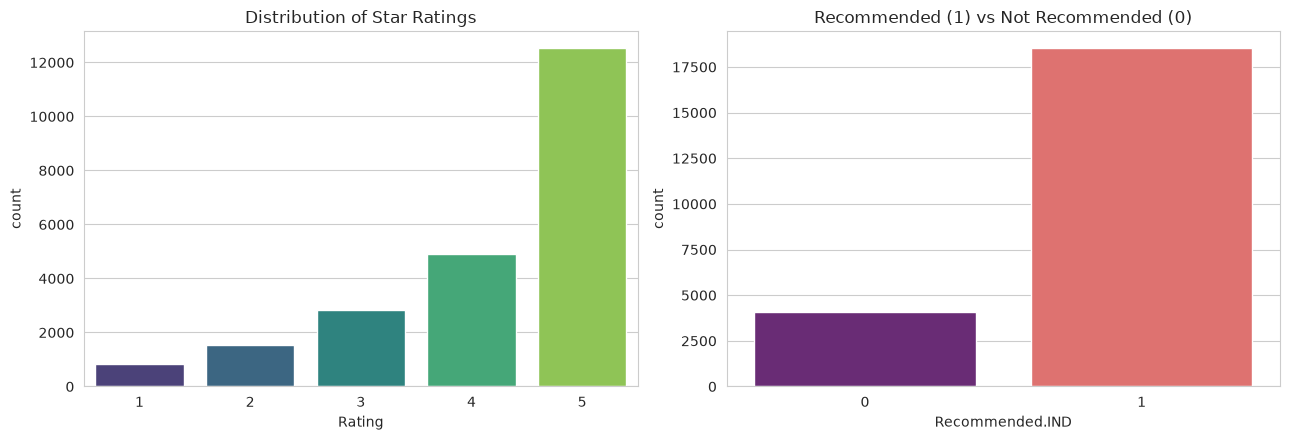

Rating
1    0.036
2    0.068
3    0.125
4    0.217
5    0.554
Name: proportion, dtype: float64


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot (x="Rating", data=df_clean, palette="viridis", ax=axes [0])
axes[0].set_title("Distribution of Star Ratings")
sns.countplot (x="Recommended.IND", data=df_clean, palette="magma", ax=axes [1])
axes [1].set_title("Recommended (1) vs Not Recommended (0)")
plt.tight_layout(); plt.show()

print(df_clean["Rating"].value_counts(normalize=True).round(3).sort_index())

1 - Rating Distribution: The dataset is heavily skewed toward positive feedback. Over 55% of customers gave a 5-star rating, and more than 75% of reviews are 4 stars or higher.

2 - Recommendation Rate: Approximately 82% of customers recommend the products they purchased, which aligns with the high frequency of 4 and 5-star ratings.

3 - Class Imbalance: There is a significant imbalance between positive and negative/neutral reviews. This is an important consideration for the Generative AI pipeline, as the model will have fewer examples of negative feedback to learn from compared to positive praise.

## Age Distribution-

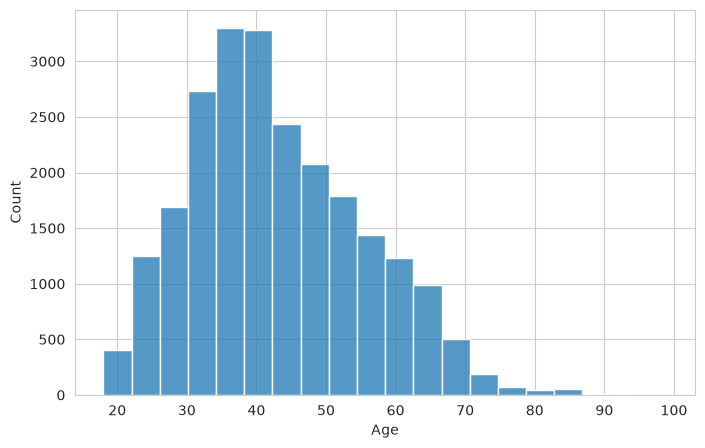

In [50]:
# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(mydata['Age'], bins=20)
plt.show()


## Rating Distribution-

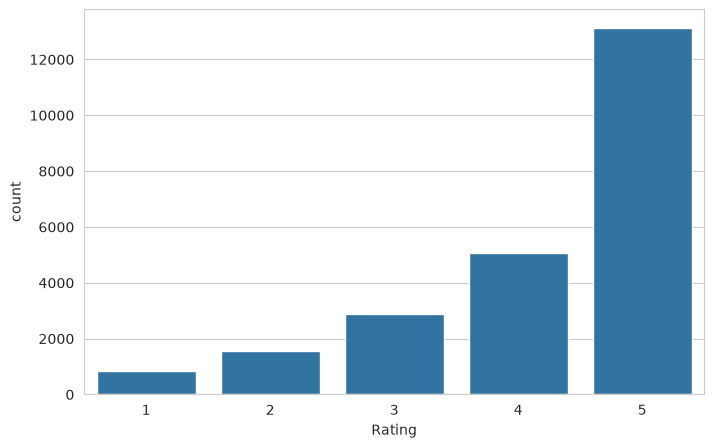

In [51]:
# Rating Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Rating', data=mydata)
plt.show()


## Recommendation Distribution-

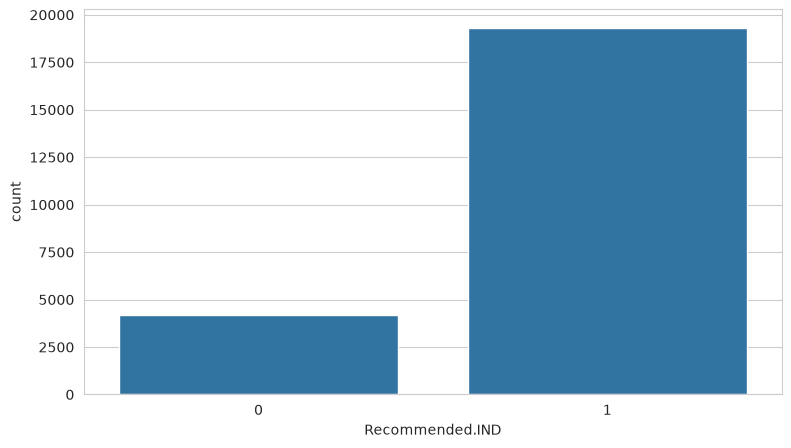

In [52]:
# Recommendation Distribution
sns.countplot(
    x='Recommended.IND',
    data=mydata
)
plt.show()


## Department Distribution

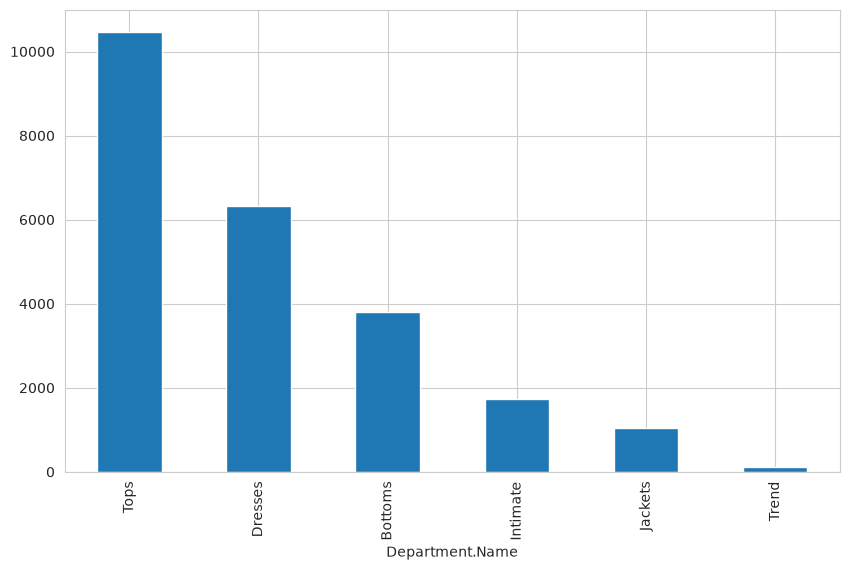

In [53]:
# Department Distribution
plt.figure(figsize=(10,6))

mydata['Department.Name'].value_counts().plot(kind='bar')

plt.show()


# Bivariate Analysis-

## Rating vs Recommendation

In [54]:
pd.crosstab(
    mydata['Rating'],
    mydata['Recommended.IND']
)


Recommended.IND,0,1
Rating,,
1,826,16
2,1471,94
3,1682,1189
4,168,4909
5,25,13106


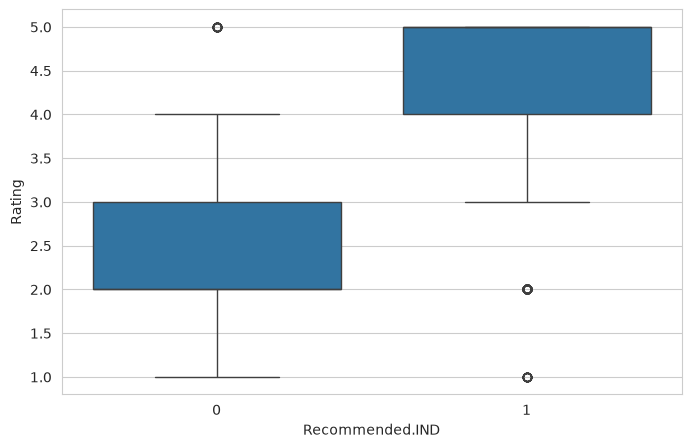

In [55]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Recommended.IND',
    y='Rating',
    data=mydata
)

plt.show()

## Department vs Rating

In [56]:
# Department vs Rating
pd.crosstab(
    mydata['Department.Name'],
    mydata['Rating']
)

Rating,1,2,3,4,5
Department.Name,,,,,
Bottoms,115,205,421,785,2273
Dresses,228,461,838,1395,3397
Intimate,63,90,178,371,1033
Jackets,49,60,91,201,631
Tops,376,738,1324,2299,5731
Trend,11,11,19,26,52


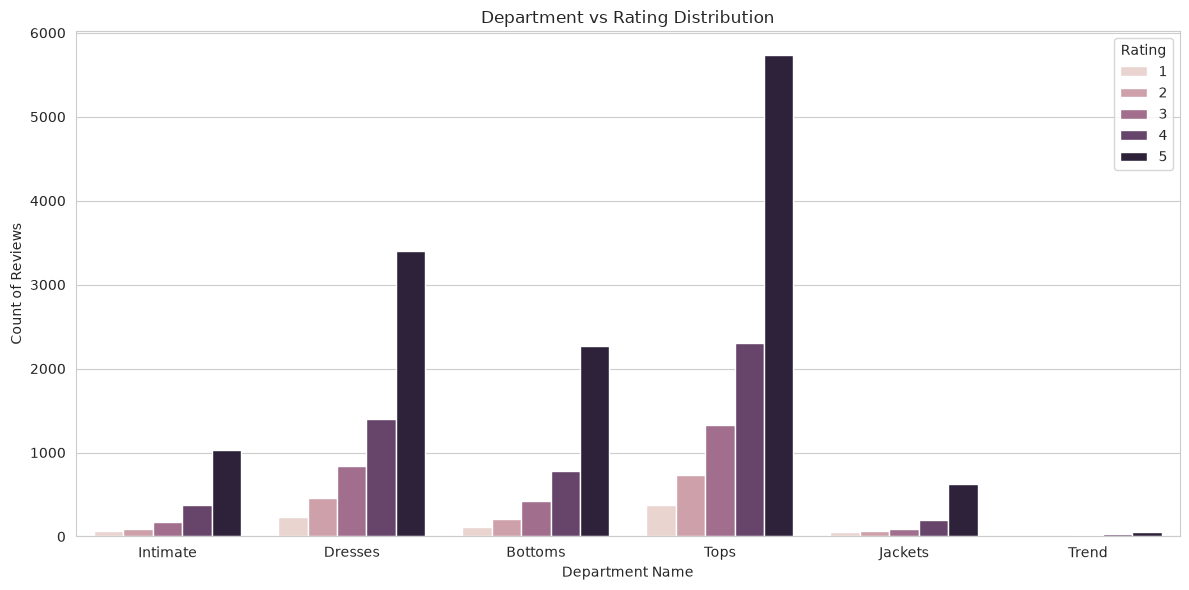

In [57]:
# Department vs Rating
pd.crosstab(
    mydata['Department.Name'],
    mydata['Rating']
)

plt.figure(figsize=(12,6))

sns.countplot(
    x='Department.Name',
    hue='Rating',
    data=mydata
)

plt.title("Department vs Rating Distribution")
plt.xlabel("Department Name")
plt.ylabel("Count of Reviews")
plt.legend(title='Rating', loc='upper right')
plt.tight_layout()
plt.show()

### **Observations: Department vs Rating**

1.  **High Volume Departments**: The 'Tops' and 'Dresses' departments receive the highest volume of reviews. While they have the most 5-star ratings, they also show a higher count of 1-star and 2-star ratings due to the sheer volume of transactions.
2.  **Sentiment Skew**: Across all departments, the distribution is heavily skewed toward 5-star ratings, reinforcing the earlier observation that the dataset is dominated by positive sentiment.
3.  **Low Volume Departments**: The 'Trend' department has significantly fewer reviews compared to others, which might make sentiment analysis for this specific category less statistically robust.
4.  **Consistency**: No single department shows a disproportionately high negative sentiment relative to its size, suggesting that quality issues (if any) are likely distributed across the product range rather than isolated to one specific department.

## Age vs Rating

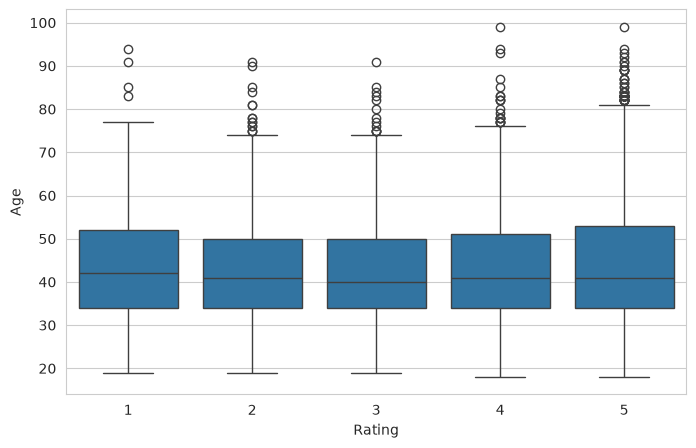

In [58]:
# Age vs Rating
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Rating',
    y='Age',
    data=mydata
)

plt.show()


# Review Length Analysis

In [59]:
# Create Review Length Analysis
mydata['Review_Length'] = mydata['Full_Review'].apply(len)
print(mydata['Review_Length'].describe())

count    23486.000000
mean       316.943371
std        155.850036
min         10.000000
25%        191.000000
50%        311.000000
75%        472.000000
max        558.000000
Name: Review_Length, dtype: float64


Observation:

- The **average** review length is approximately 317 characters, with a standard deviation of about 156 characters, indicating a moderate spread in review lengths.
- Reviews range from a minimum of 10 characters to a maximum of 558 characters.
- The median review length is 311 characters, suggesting that half of the reviews are shorter than this length and half are longer. The 25th percentile is 191 characters, and the 75th percentile is 472 characters.

Distribution-

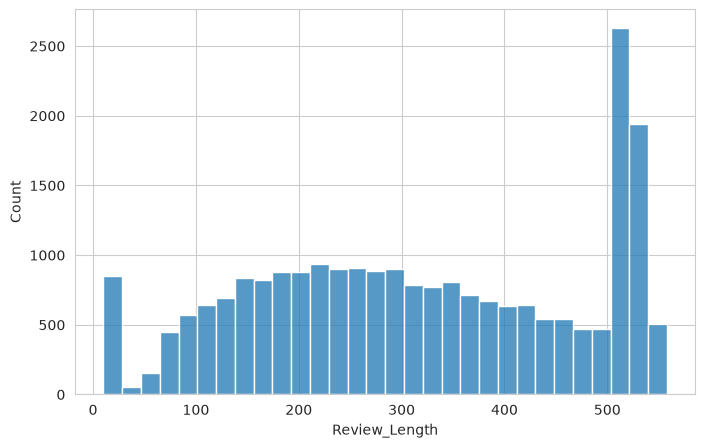

In [60]:
# Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    mydata['Review_Length'],
    bins=30
)

plt.show()


### Review Response

In [61]:
# Average rating & negative-review share per department -> tells us WHERE urgent issues concentrate
dept_stats = df_clean.groupby("Department.Name").agg(
    avg_rating=("Rating", "mean"),
    n_reviews=("Rating", "size"),
    pct_low_rating=("Rating", lambda x: (x <= 2).mean() * 100)
).sort_values("pct_low_rating", ascending=False).round(2)

dept_stats

,avg_rating,n_reviews,pct_low_rating
Department.Name,,,
Trend,3.84,118,17.80
Dresses,4.14,6144,11.07
Tops,4.16,10048,10.91
Jackets,4.25,1002,10.78
Intimate,4.27,1653,8.89
Bottoms,4.28,3661,8.66


Observation-

- Highest Risk Area: The Trend department has the highest percentage of low ratings (17.80%) and the lowest average rating (3.84). This suggests that products in this category may have consistent issues with quality or expectations.
- High Volume Concerns: While Dresses and Tops have much higher volumes of reviews (~6k and ~10k respectively), they maintain a low-rating share of around 11%. Because of their high volume, these departments likely generate the highest absolute number of complaints for the retail team to handle.
- Best Performing Area: Bottoms and Intimate departments show the highest customer satisfaction, with the lowest percentage of negative reviews (under 9%) and the highest average ratings (~4.28).


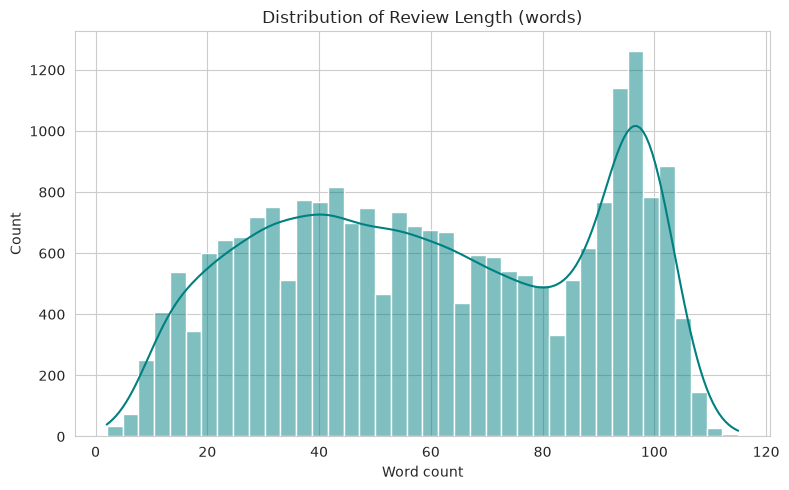

count    22626.000000
mean        60.211173
std         28.533065
min          2.000000
25%         36.000000
50%         59.000000
75%         88.000000
max        115.000000
Name: Review.Length, dtype: float64


In [62]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["Review.Length"], bins=40, kde=True, color="teal")
plt.title("Distribution of Review Length (words)")
plt.xlabel("Word count")
plt.tight_layout()
plt.show()
print(df_clean["Review.Length"].describe())

### **Observation: Review Length Distribution**

*   **Central Tendency:** The average review length is approximately **60 words**, with a median of **59 words**, indicating a relatively symmetrical distribution of review lengths around the mean.
*   **Range and Spread:** Reviews vary significantly in detail, ranging from very brief comments of just **2 words** to comprehensive feedback of up to **115 words**. The standard deviation of **28.5 words** confirms this moderate variation.
*   **Typical Review Profile:** 50% of the reviews fall between **36 and 88 words** (the interquartile range). This suggests that most customers provide enough detail to be useful for sentiment and issue extraction, though the very short reviews (minimum of 2 words) may lack sufficient context for deep AI analysis.

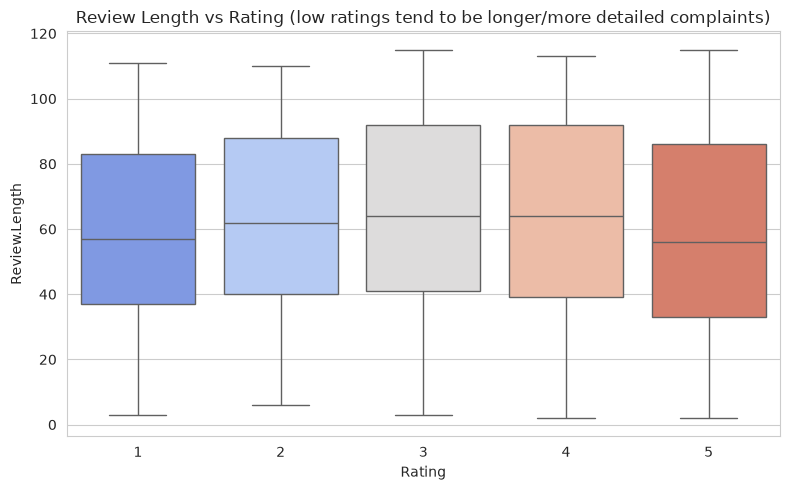

In [63]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Rating", y="Review.Length", data=df_clean, palette="coolwarm")
plt.title("Review Length vs Rating (low ratings tend to be longer/more detailed complaints)")
plt.tight_layout()
plt.show()

### **Observation: Review Length vs Rating**

*   **Correlation with Sentiment:** There is a noticeable trend where **lower ratings (1 and 2 stars) tend to have a wider range and slightly higher median word count** compared to 5-star reviews.
*   **Detailed Complaints:** This suggests that dissatisfied customers often write more detailed, descriptive reviews to explain specific issues or frustrations, whereas satisfied customers are more likely to leave brief, positive affirmations.
*   **Actionable Feedback:** For the retail team, longer reviews associated with low ratings likely contain high-value diagnostic information about product defects or sizing issues, making them critical for the Generative AI pipeline to summarize accurately.

## Positive Reviews

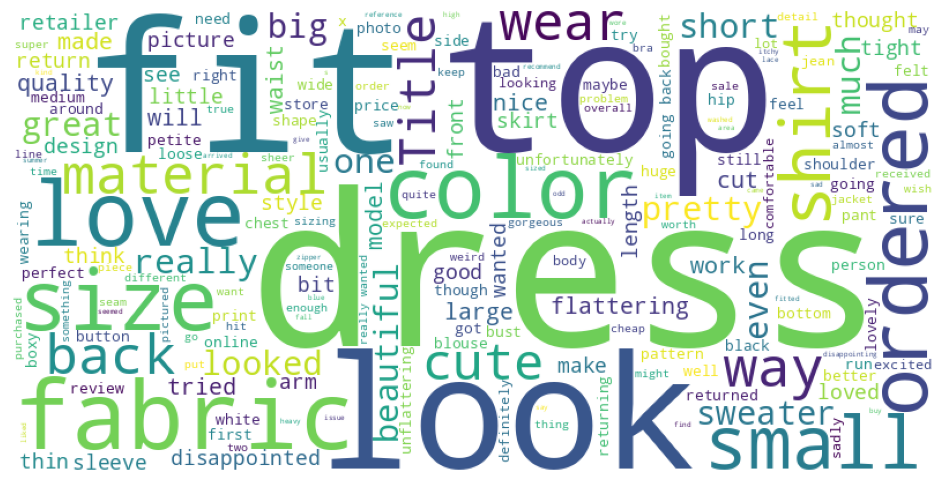

In [64]:
positive_reviews = " ".join(
    mydata[mydata['Rating']<4]['Full_Review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()


In [65]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Select positive reviews (Rating >= 4)
positive_reviews = mydata[mydata['Rating'] >= 4]['Full_Review'].dropna()

# Create the document-term matrix
cv = CountVectorizer(stop_words='english')
X = cv.fit_transform(positive_reviews)

# Calculate word frequencies
word_freq = pd.DataFrame({
    'word': cv.get_feature_names_out(),
    'count': X.sum(axis=0).A1
}).sort_values(by='count', ascending=False)

# Display the top 20 most frequent words
word_freq.head(20)

,word,count
3628,dress,9510
6577,love,9427
9946,size,7250
5033,great,7041
4402,fit,5984
12110,wear,5512
6390,like,5049
8011,perfect,4303
6015,just,4163
2475,color,3856


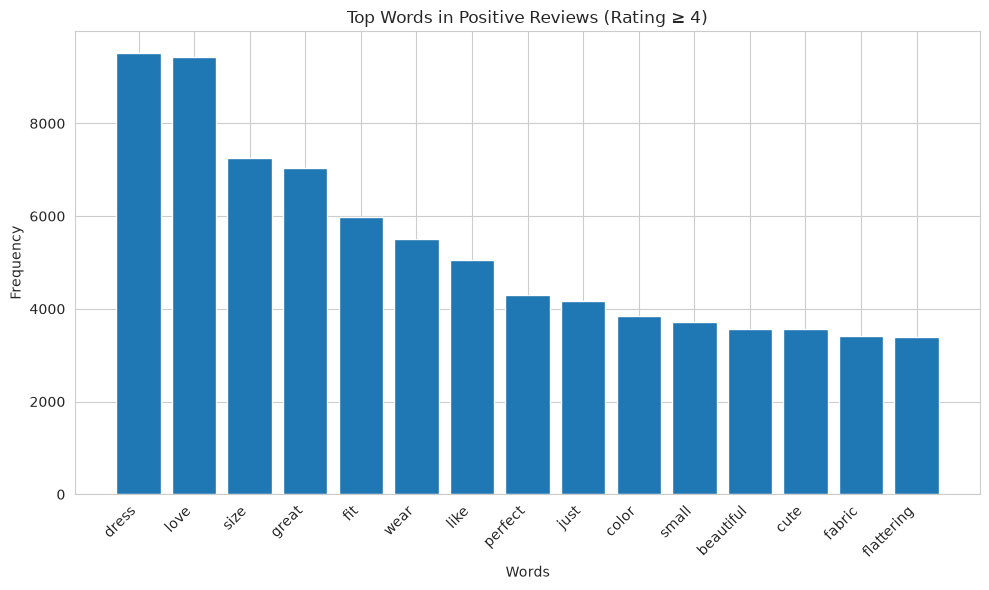

In [66]:
import matplotlib.pyplot as plt

# Take top 15 words
top_words = word_freq.head(15)

plt.figure(figsize=(10, 6))
plt.bar(top_words['word'], top_words['count'])

plt.title("Top Words in Positive Reviews (Rating ≥ 4)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Negative Reviews

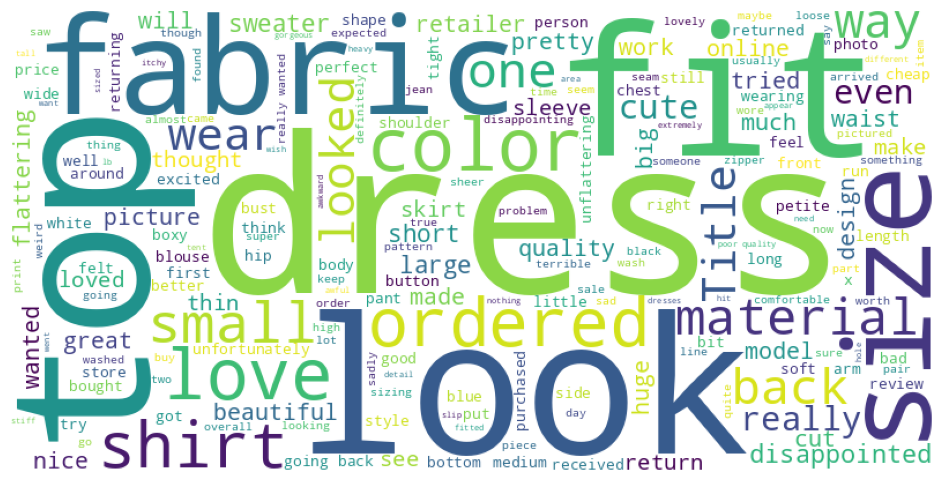

In [67]:
# Negative Reviews
negative_reviews = " ".join(
    mydata[mydata['Rating']<=2]['Full_Review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()


In [68]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Select negative reviews (Rating <= 2)
negative_reviews = mydata[mydata['Rating'] <= 2]['Full_Review'].dropna()

# Create the document-term matrix
cv = CountVectorizer(stop_words='english')
X = cv.fit_transform(negative_reviews)

# Calculate word frequencies
word_freq = pd.DataFrame({
    'word': cv.get_feature_names_out(),
    'count': X.sum(axis=0).A1
}).sort_values(by='count', ascending=False)

# Display the top 20 most frequent words
word_freq.head(20)

,word,count
1524,dress,1188
2669,like,1141
1846,fit,797
1740,fabric,782
2512,just,687
4186,size,687
4254,small,573
2745,love,533
2716,look,530
3177,ordered,513


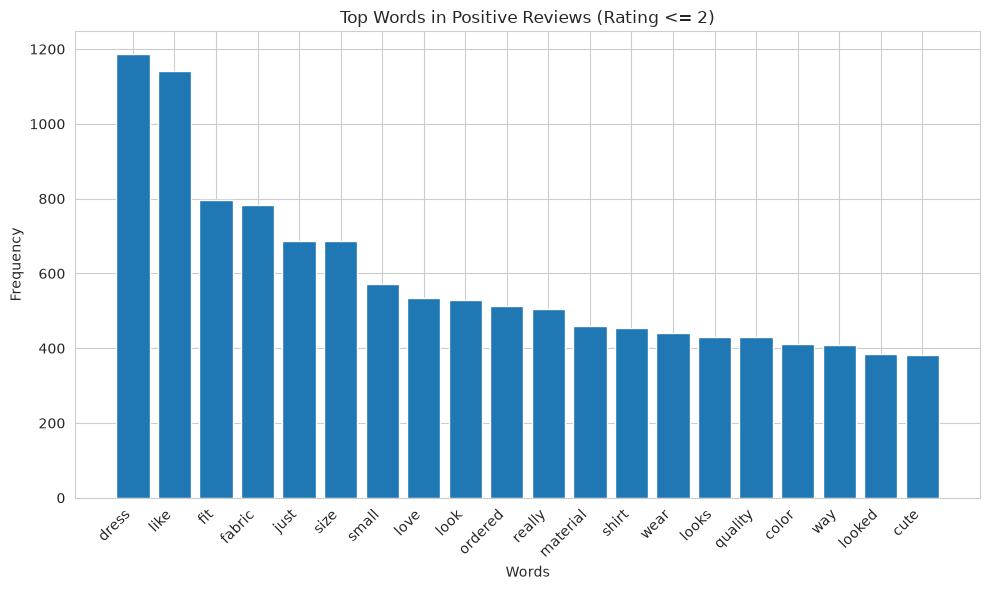

In [69]:
import matplotlib.pyplot as plt

# Take top 15 words
top_words = word_freq.head(20)

plt.figure(figsize=(10, 6))
plt.bar(top_words['word'], top_words['count'])

plt.title("Top Words in Positive Reviews (Rating <= 2)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Neutral Review-

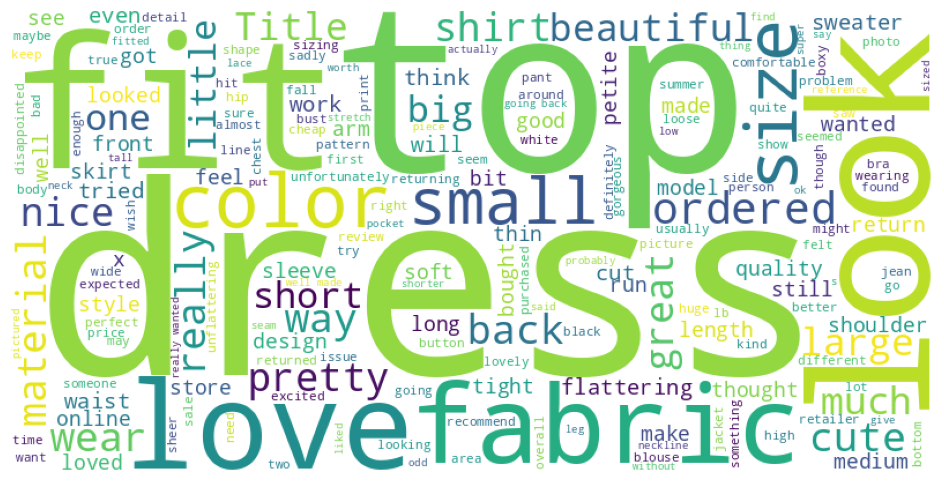

In [70]:
# Neutral Reviews
Neutral_reviews = " ".join(
    mydata[mydata['Rating']==3]['Full_Review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(Neutral_reviews)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [71]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Select Neutral reviews (Rating == 3)
Neutral_reviews = mydata[mydata['Rating'] == 3]['Full_Review'].dropna()

# Create the document-term matrix
cv = CountVectorizer(stop_words='english')
X = cv.fit_transform(Neutral_reviews)

# Calculate word frequencies
word_freq = pd.DataFrame({
    'word': cv.get_feature_names_out(),
    'count': X.sum(axis=0).A1
}).sort_values(by='count', ascending=False)

# Display the top 20 most frequent words
word_freq.head(20)

,word,count
1644,dress,1523
2868,like,1197
1983,fit,1157
4448,size,1039
2702,just,984
1876,fabric,895
2947,love,859
4519,small,771
2917,look,707
3909,really,667


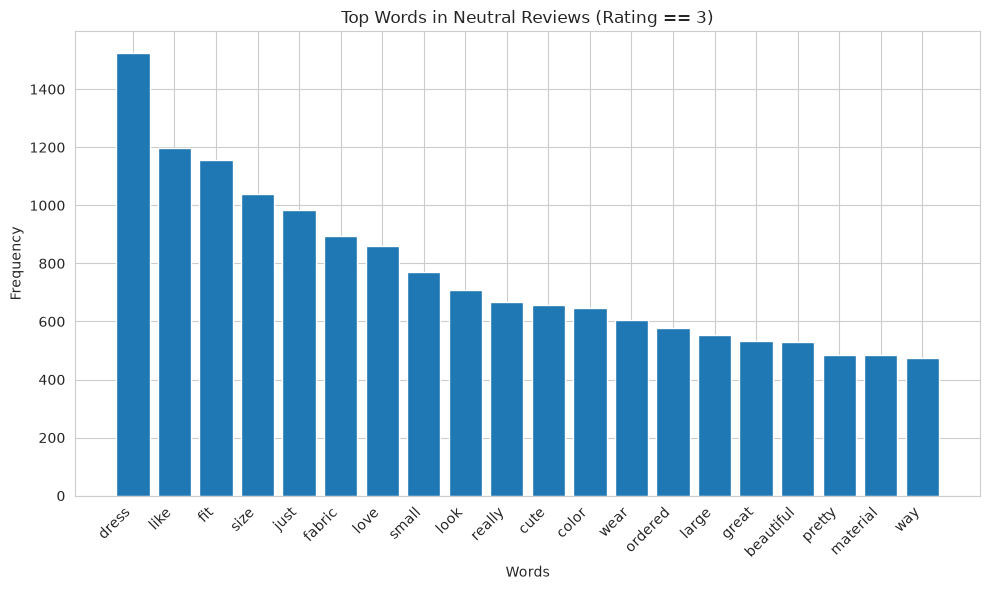

In [72]:
import matplotlib.pyplot as plt

# Take top 15 words
top_words = word_freq.head(20)

plt.figure(figsize=(10, 6))
plt.bar(top_words['word'], top_words['count'])

plt.title("Top Words in Neutral Reviews (Rating == 3)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

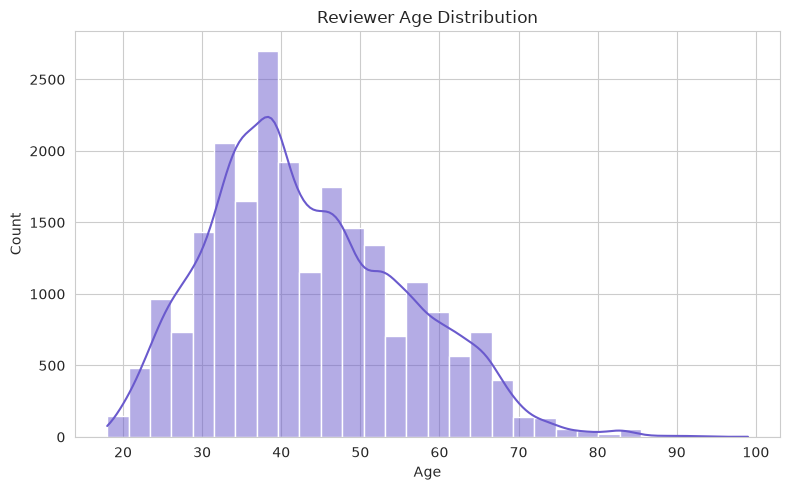

In [73]:
plt.figure(figsize=[8, 5])
sns.histplot(df_clean["Age"], bins=30, kde=True, color="slateblue")
plt.title("Reviewer Age Distribution")
plt.tight_layout(); plt.show()

Observation-

1 - Core Demographic: The majority of reviewers are between 30 and 50 years old.
Peak Activity: The distribution peaks around age 39-42, indicating this is the most active group leaving feedback.

2 - Broad Range: While the core group is middle-aged, the brand attracts feedback from a wide range of customers, from age 18 up to nearly 100.

3 - Normal Distribution: The data follows a roughly normal distribution with a slight right skew toward older ages.

## Building the Generative AI Pipeline

We will now build a system to analyze the reviews using **Gemini API**. The pipeline includes API setup, prompt design, structured JSON generation, and LLM-as-Judge evaluation.

The cleaned notebook uses a single `call_llm()` wrapper so that Zero-Shot, Few-Shot, Chain-of-Thought, and Judge calls are evaluated consistently.


In [74]:
custom_stopwords = [
    "dress",
    "product",
    "item",
    "wear",
    "bought"
]

cv = CountVectorizer(
    stop_words='english',
    max_features=50
)

CountVectorizer(
    stop_words='english',
    ngram_range=(2,2),
    max_features=20
)

,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(2, ...)"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",20
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'


In [75]:
mydata['Rating'].value_counts().sort_index()

,count
Rating,
1,842
2,1565
3,2871
4,5077
5,13131


## Validate Review Counts

In [76]:
# validate review count this will help in class imbalance
print("Positive:", (mydata['Rating']>=4).sum())
print("Neutral :", (mydata['Rating']==3).sum())
print("Negative:", (mydata['Rating']<=2).sum())

Positive: 18208
Neutral : 2871
Negative: 2407


## **Building the Generative AI Pipeline**

We will now build a system to analyze the reviews using **Gemini API**. This involves setting up the Gemini client, designing prompts, generating structured data, and evaluating results with an LLM-as-Judge.


## Prepare Data for LLM

Create sentiment labels, this will allow us to compare LLM outputs with the original ratings

In [77]:
# Create sentiment labels from ratings
def sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

mydata["Actual_Sentiment"] = mydata["Rating"].apply(sentiment_label)

mydata[["Rating","Actual_Sentiment"]].head()

,Rating,Actual_Sentiment
0,4,Positive
1,5,Positive
2,3,Neutral
3,5,Positive
4,5,Positive


Observation

Ratings were converted into sentiment labels to provide a baseline for comparing LLM-generated sentiment predictions.

## Sample Selection for API

Testing Sample

In [78]:
sample_10 = mydata.sample(
    n=10,
    random_state=42
).reset_index(drop=True)

sample_10

,Unnamed: 0,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,Full_Review,Review_Length,Clean_Review,Actual_Sentiment
0,1298,1095,34,Size up if busty,I agree with the other reviewer that the color...,4,1,19,General,Dresses,Dresses,Size up if busty. I agree with the other revie...,518,size up if busty. i agree with the other revie...,Positive
1,7229,903,57,Snap front hoodie,I have many sweaters but i bought this during ...,4,1,0,General Petite,Tops,Fine gauge,Snap front hoodie. I have many sweaters but i ...,110,snap front hoodie. i have many sweaters but i ...,Positive
2,21411,830,56,Adorable,Beautiful top but runs a whole size small. gav...,4,1,3,General,Tops,Blouses,Adorable. Beautiful top but runs a whole size ...,83,adorable. beautiful top but runs a whole size ...,Positive
3,8359,1047,36,Fraying after 2 wears!,I loved these pants.they are so comfortable. h...,3,0,3,General Petite,Bottoms,Pants,Fraying after 2 wears!. I loved these pants.th...,524,fraying after 2 wears!. i loved these pants.th...,Neutral
4,20841,1110,30,Fabulous material....,I ordered this dress in a petite but it arrive...,5,1,0,General,Dresses,Dresses,Fabulous material..... I ordered this dress in...,414,fabulous material..... i ordered this dress in...,Positive
5,8194,820,36,Run and buy.....,Such a cute shirt! i picked up the white-with-...,5,1,11,General Petite,Tops,Blouses,Run and buy...... Such a cute shirt! i picked ...,518,run and buy...... such a cute shirt! i picked ...,Positive
6,17262,1059,37,No Title,Had to send back for exchange. way too big. i'...,3,1,2,General Petite,Bottoms,Pants,No Title. Had to send back for exchange. way t...,134,no title. had to send back for exchange. way t...,Neutral
7,6073,1092,39,Sbags easily,I liked this dress but wasn't sure about the c...,5,1,5,General,Dresses,Dresses,Sbags easily. I liked this dress but wasn't su...,514,sbags easily. i liked this dress but wasn't su...,Positive
8,10802,22,30,Please bring this shirt back!!!,This is my favorite shirt ever. i've had it fo...,5,1,0,General,Tops,Knits,Please bring this shirt back!!!. This is my fa...,143,please bring this shirt back!!!. this is my fa...,Positive
9,15106,394,30,No Title,,5,1,0,Initmates,Intimate,Swim,No Title.,10,no title.,Positive


Observation

A random sample of 10 reviews was selected for API testing to reduce processing time and API costs.

Final Evaluation Sample

In [79]:
# Create a random sample of 50 reviews
sample_50 = mydata.sample(n=50, random_state=42).reset_index(drop=True)

# Display the first 5 records
sample_50.head()

# View All 50 Records
sample_50
display(sample_50)

# Verify the Number of Records
print("Number of reviews in sample:", len(sample_50))

,Unnamed: 0,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,Full_Review,Review_Length,Clean_Review,Actual_Sentiment
0,1298,1095,34,Size up if busty,I agree with the other reviewer that the color...,4,1,19,General,Dresses,Dresses,Size up if busty. I agree with the other revie...,518,size up if busty. i agree with the other revie...,Positive
1,7229,903,57,Snap front hoodie,I have many sweaters but i bought this during ...,4,1,0,General Petite,Tops,Fine gauge,Snap front hoodie. I have many sweaters but i ...,110,snap front hoodie. i have many sweaters but i ...,Positive
2,21411,830,56,Adorable,Beautiful top but runs a whole size small. gav...,4,1,3,General,Tops,Blouses,Adorable. Beautiful top but runs a whole size ...,83,adorable. beautiful top but runs a whole size ...,Positive
3,8359,1047,36,Fraying after 2 wears!,I loved these pants.they are so comfortable. h...,3,0,3,General Petite,Bottoms,Pants,Fraying after 2 wears!. I loved these pants.th...,524,fraying after 2 wears!. i loved these pants.th...,Neutral
4,20841,1110,30,Fabulous material....,I ordered this dress in a petite but it arrive...,5,1,0,General,Dresses,Dresses,Fabulous material..... I ordered this dress in...,414,fabulous material..... i ordered this dress in...,Positive
5,8194,820,36,Run and buy.....,Such a cute shirt! i picked up the white-with-...,5,1,11,General Petite,Tops,Blouses,Run and buy...... Such a cute shirt! i picked ...,518,run and buy...... such a cute shirt! i picked ...,Positive
6,17262,1059,37,No Title,Had to send back for exchange. way too big. i'...,3,1,2,General Petite,Bottoms,Pants,No Title. Had to send back for exchange. way t...,134,no title. had to send back for exchange. way t...,Neutral
7,6073,1092,39,Sbags easily,I liked this dress but wasn't sure about the c...,5,1,5,General,Dresses,Dresses,Sbags easily. I liked this dress but wasn't su...,514,sbags easily. i liked this dress but wasn't su...,Positive
8,10802,22,30,Please bring this shirt back!!!,This is my favorite shirt ever. i've had it fo...,5,1,0,General,Tops,Knits,Please bring this shirt back!!!. This is my fa...,143,please bring this shirt back!!!. this is my fa...,Positive
9,15106,394,30,No Title,,5,1,0,Initmates,Intimate,Swim,No Title.,10,no title.,Positive


Number of reviews in sample: 50


Save the Sample for Reuse (Recommended) This ensures you use the same 50 reviews throughout the project.

In [80]:
sample_50.to_csv("sample_50_reviews.csv", index=False)

print("Sample saved successfully!")

Sample saved successfully!


In [81]:
# Display Only the Relevant Columns.
sample_50[['Clothing.ID',
           'Department.Name',
           'Rating',
           'Full_Review']]

,Clothing.ID,Department.Name,Rating,Full_Review
0,1095,Dresses,4,Size up if busty. I agree with the other revie...
1,903,Tops,4,Snap front hoodie. I have many sweaters but i ...
2,830,Tops,4,Adorable. Beautiful top but runs a whole size ...
3,1047,Bottoms,3,Fraying after 2 wears!. I loved these pants.th...
4,1110,Dresses,5,Fabulous material..... I ordered this dress in...
5,820,Tops,5,Run and buy...... Such a cute shirt! i picked ...
6,1059,Bottoms,3,No Title. Had to send back for exchange. way t...
7,1092,Dresses,5,Sbags easily. I liked this dress but wasn't su...
8,22,Tops,5,Please bring this shirt back!!!. This is my fa...
9,394,Intimate,5,No Title.


Check the Sample Distribution (Good Practice), Make sure your sample isn't heavily skewed toward one rating.

In [82]:
sample_50['Rating'].value_counts().sort_index()

sample_50[['Department.Name', 'Rating']].value_counts().sort_index()

Department.Name  Rating
Bottoms          3          3
                 4          1
                 5          4
Dresses          2          1
                 3          5
                 4          3
                 5         11
Intimate         4          2
                 5          1
Tops             1          1
                 2          1
                 3          1
                 4          4
                 5         12
Name: count, dtype: int64

Instead of taking a purely random sample, consider a stratified sample so that all rating levels (1–5) are represented. This gives a more balanced evaluation of your prompting techniques.

In [83]:
sample_50 = (
    mydata.groupby('Rating', group_keys=False)
          .apply(lambda x: x.sample(min(10, len(x)), random_state=42))
          .reset_index(drop=True)
)

sample_50.head()

,Unnamed: 0,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,Full_Review,Review_Length,Clean_Review,Actual_Sentiment
0,14289,879,27,Terrible fabric,I loved the shirt until i washed it! awful fab...,1,0,0,General Petite,Tops,Knits,Terrible fabric. I loved the shirt until i was...,89,terrible fabric. i loved the shirt until i was...,Negative
1,6446,295,51,No Title,This shirt fits very closely to the body. it h...,1,0,3,Initmates,Intimate,Layering,No Title. This shirt fits very closely to the ...,303,no title. this shirt fits very closely to the ...,Negative
2,17460,1119,38,Great idea..poor execution,I tried on an xs and it was boxy/roomy in the ...,1,0,0,General,Jackets,Outerwear,Great idea..poor execution. I tried on an xs a...,528,great idea..poor execution. i tried on an xs a...,Negative
3,20507,870,40,No Title,So unflattering! really disappointed. made me ...,1,0,0,General,Tops,Knits,No Title. So unflattering! really disappointed...,102,no title. so unflattering! really disappointed...,Negative
4,1985,1016,67,Mission impossible,What an adorable and frustrating skirt! i'm no...,1,0,13,General,Bottoms,Skirts,Mission impossible. What an adorable and frust...,361,mission impossible. what an adorable and frust...,Negative


Observation-

This attempts to select up to 10 reviews from each rating, giving you a balanced dataset across positive, neutral, and negative feedback. This is often a better choice for evaluating prompt quality than a purely random sample.

## Building the Generative AI Pipeline

We will now set up the Gemini client, prepare the 50-review sample, run prompt engineering experiments, and evaluate the results.

### Setup AI Client and Data Sample

**Question:** How do you initialize the Gemini client with API keys and safely test fallback keys?

**Answer:** Use Colab Secrets where possible. This notebook also includes a fallback key list because this project file was requested to test two provided keys. The code tries each key silently and selects the first key that successfully calls Gemini.


### Gemini API setup
This cleaned notebook reads the API key from Colab Secrets using the name `GEMINI_API_KEY`. Do not paste API keys directly into notebook cells.


In [84]:
# Gemini API Setup and Shared LLM Utilities - Google Colab Compatible
# IMPORTANT:
# 1. Store your Gemini Developer API key in Colab Secrets with this exact name:
#       GEMINI_API_KEY
# 2. The value should normally start with "AIza..."
# 3. Do not hard-code or share API keys in the notebook.

!pip install -q requests tenacity

import os
import re
import json
import time
import requests
from typing import Dict, Any, Optional
from tenacity import retry, stop_after_attempt, wait_random_exponential

# -----------------------------
# Read API key from Colab Secrets
# -----------------------------
GEMINI_API_KEY = None

try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
except Exception:
    GEMINI_API_KEY = None

# Optional fallback to environment variable
if not GEMINI_API_KEY:
    GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY")

if not GEMINI_API_KEY:
    raise ValueError(
        "GEMINI_API_KEY was not found. In Colab, open the Secrets panel, "
        "create a secret named GEMINI_API_KEY, paste your Gemini API key as the value, "
        "and turn Notebook access ON."
    )

# Helpful warning. Gemini Developer API keys usually start with AIza.
if not GEMINI_API_KEY.startswith("AIza"):
    print("⚠️ Warning: This key does not start with 'AIza'.")
    print("Gemini Developer API keys from Google AI Studio usually start with 'AIza'.")
    print("If API calls fail, copy the full key using the copy icon in Google AI Studio and store it as GEMINI_API_KEY.")

BASE_URL = "https://generativelanguage.googleapis.com/v1beta"

# -----------------------------
# Model discovery
# -----------------------------
def list_available_gemini_models():
    """Return Gemini models that support generateContent for this API key."""
    url = f"{BASE_URL}/models"
    response = requests.get(url, params={"key": GEMINI_API_KEY}, timeout=30)

    if response.status_code != 200:
        raise RuntimeError(
            f"Unable to list Gemini models. Status={response.status_code}. "
            f"Response={response.text[:500]}"
        )

    data = response.json()
    models = []

    for model in data.get("models", []):
        methods = model.get("supportedGenerationMethods", [])
        if "generateContent" in methods:
            models.append(model.get("name"))

    return models

available_models = list_available_gemini_models()

print("Available Gemini models:")
for model_name in available_models:
    print("-", model_name)

preferred_models = [
    "models/gemini-2.5-flash",
    "models/gemini-2.0-flash",
    "models/gemini-1.5-flash-latest",
    "models/gemini-1.5-flash"
]

GEMINI_MODEL = None

for model_name in preferred_models:
    if model_name in available_models:
        GEMINI_MODEL = model_name
        break

if GEMINI_MODEL is None:
    if len(available_models) == 0:
        raise RuntimeError("No Gemini models supporting generateContent were returned for this API key.")
    GEMINI_MODEL = available_models[0]

JUDGE_MODEL = GEMINI_MODEL

gemini_main_model = GEMINI_MODEL
gemini_judge_model = JUDGE_MODEL
USE_REAL_API = True

print("✅ Gemini API configured successfully.")
print("Main model:", GEMINI_MODEL)
print("Judge model:", JUDGE_MODEL)

# -----------------------------
# JSON parsing helper
# -----------------------------
def safe_json_parse(raw_text: str) -> Optional[Dict[str, Any]]:
    """Extract and parse a JSON object from an LLM response."""
    if raw_text is None:
        return None

    text = str(raw_text).strip()

    # Remove markdown code fences if present
    text = re.sub(r"^```json", "", text).strip()
    text = re.sub(r"^```", "", text).strip()
    text = re.sub(r"```$", "", text).strip()

    match = re.search(r"\{.*\}", text, re.DOTALL)

    if not match:
        return None

    try:
        return json.loads(match.group(0))
    except json.JSONDecodeError:
        return None

# -----------------------------
# Gemini REST call helper
# -----------------------------
@retry(wait=wait_random_exponential(min=1, max=20), stop=stop_after_attempt(5))
def call_gemini_text(system_prompt: str, user_prompt: str, model_instance=None, temperature: float = 0) -> str:
    """Call Gemini and return raw text. model_instance can be a model-name string."""
    if not USE_REAL_API:
        raise RuntimeError("Gemini API is not configured.")

    model_name = model_instance if model_instance else GEMINI_MODEL

    full_prompt = f"{system_prompt}\n\n{user_prompt}"

    url = f"{BASE_URL}/{model_name}:generateContent"

    payload = {
        "contents": [
            {
                "role": "user",
                "parts": [
                    {
                        "text": full_prompt
                    }
                ]
            }
        ],
        "generationConfig": {
            "temperature": temperature
        }
    }

    response = requests.post(
        url,
        params={"key": GEMINI_API_KEY},
        headers={"Content-Type": "application/json"},
        json=payload,
        timeout=120
    )

    if response.status_code != 200:
        raise RuntimeError(
            f"Gemini call failed. Status={response.status_code}. "
            f"Response={response.text[:1000]}"
        )

    data = response.json()

    try:
        return data["candidates"][0]["content"]["parts"][0]["text"]
    except Exception:
        return json.dumps(data)

# -----------------------------
# Single entry point for all prompting techniques
# -----------------------------
def call_llm(system_prompt: str, user_prompt: str, model: str = None, judge: bool = False) -> Dict[str, Any]:
    """Call Gemini and return parsed JSON. Falls back to a safe dictionary if output is not valid JSON."""
    selected_model = gemini_judge_model if judge or model == JUDGE_MODEL else gemini_main_model

    try:
        raw = call_gemini_text(
            system_prompt=system_prompt,
            user_prompt=user_prompt,
            model_instance=selected_model,
            temperature=0
        )

        parsed = safe_json_parse(raw)

        if parsed is None:
            return {
                "Category": "Unknown",
                "Sentiment": "Neutral",
                "Summary": raw[:300] if raw else "",
                "Personalized_Message": "Thank you for sharing your feedback.",
                "Retail_Insight": "Review this feedback manually for further action.",
                "Urgency": "Low",
                "Aspects": []
            }

        return parsed

    except Exception as e:
        return {
            "Category": "Error",
            "Sentiment": "Error",
            "Summary": f"LLM call failed: {str(e)}",
            "Personalized_Message": "",
            "Retail_Insight": "",
            "Urgency": "Unknown",
            "Aspects": []
        }

print("Shared Gemini utilities ready: safe_json_parse(), call_gemini_text(), call_llm().")


⚠️ Warning: This key does not start with 'AIza'.
Gemini Developer API keys from Google AI Studio usually start with 'AIza'.
If API calls fail, copy the full key using the copy icon in Google AI Studio and store it as GEMINI_API_KEY.
Available Gemini models:
- models/gemini-2.5-flash
- models/gemini-2.5-pro
- models/gemini-2.0-flash
- models/gemini-2.0-flash-001
- models/gemini-2.0-flash-lite-001
- models/gemini-2.0-flash-lite
- models/gemini-2.5-flash-preview-tts
- models/gemini-2.5-pro-preview-tts
- models/gemma-4-26b-a4b-it
- models/gemma-4-31b-it
- models/gemini-flash-latest
- models/gemini-flash-lite-latest
- models/gemini-pro-latest
- models/gemini-2.5-flash-lite
- models/gemini-2.5-flash-image
- models/gemini-3-pro-preview
- models/gemini-3-flash-preview
- models/gemini-3.1-pro-preview
- models/gemini-3.1-pro-preview-customtools
- models/gemini-3.1-flash-lite-preview
- models/gemini-3.1-flash-lite
- models/gemini-3-pro-image-preview
- models/gemini-3-pro-image
- models/nano-banan

In [85]:
# Quick Gemini sanity check
if USE_REAL_API:
    test_response = call_gemini_text(
        "You are a helpful assistant.",
        "Return exactly: Gemini is working",
        model_instance=gemini_main_model,
        temperature=0
    )
    print(test_response)
else:
    print("Gemini is not configured. Please update the API key setup cell.")


Gemini is working


In [86]:
from google import genai
from google.colab import userdata

client = genai.Client(
    api_key=userdata.get("GEMINI_API_KEY")
)

for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.5-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-pr

In [87]:
import time
import os
import json

CACHE_FILE = "gemini_cache.json"

if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE, "r") as f:
        cache = json.load(f)
else:
    cache = {}

def cached_gemini_call(prompt, model_name=GEMINI_MODEL):
    if prompt in cache:
        return cache[prompt]

    try:
        response = client.models.generate_content(
            model=model_name,
            contents=prompt
        )

        result = response.text
        cache[prompt] = result

        with open(CACHE_FILE, "w") as f:
            json.dump(cache, f)

        time.sleep(3) # Add a small delay to respect rate limits
        return result

    except Exception as e:
        if "429" in str(e): # Quota/rate limit error
            print("Quota/rate limit reached. Waiting 60 seconds...")
            time.sleep(60)
            return cached_gemini_call(prompt, model_name) # Retry the call
        else:
            raise e

In [88]:
from google import genai
from google.colab import userdata

# Ensure 'client' is defined if not already in scope from previous cells
# Assuming client is already defined globally by the setup cells

# Assuming GEMINI_MODEL is already defined globally by the setup cells

# Use the cached_gemini_call function to handle rate limits and caching
response_text = cached_gemini_call(
    prompt="Return exactly OK.",
    model_name=GEMINI_MODEL
)

print(response_text)

OK


In [89]:
# save Sample
sample_50.to_csv('sample_50.csv', index=False)

#### **Note:**

For this project, we will analyze and categorize a sample of **50 customer reviews**. This number is chosen intentionally. Since the API has a **budget limit of $20**, running prompts on very large datasets can quickly exhaust your quota—especially because this exercise may involve **multiple iterations, prompt refinements, and repeated evaluations**.

To avoid unnecessary cost and ensure efficient experimentation, we recommend the following approach:

*   **Use very small samples (5–10 reviews)** during the **initial testing phase** to validate your prompt structure and logic.
    
*   **Scale up to 50 reviews** for the **final evaluation phase**, ensuring you get enough data to compare prompting techniques without draining your budget.
    
*   This strategy helps maintain cost control while still providing meaningful insights across Zero-Shot, Few-Shot, and Chain-of-Thought techniques.
    

If your API quota gets exhausted, you may temporarily switch to another free AI assistant API. However, note that external tools may also have **rate limits** or **token caps**, so you will need to build retry logic and manage throttling within your code.

In [90]:
# API setup is handled in the Gemini setup cell above.
# No OpenAI/Ollama client is required for this cleaned notebook.


#### **Prompt Engineering and Evaluation**

We will test three different prompting techniques. For each, we will create a basic version (V1) and an enhanced version (V2).

**Think about it:** Why is it important to have a consistent and robust evaluation framework? How can we use an "LLM-as-Judge" to score the quality of our generated outputs objectively?

#### **Technique 1: Zero-Shot Prompting**

**Questions:**

1.  How would you design a basic Zero-Shot prompt that asks the model for Category, Sentiment, Summary, Personalized Message, and Retail Insight?
    
2.  How can you enhance this prompt with more business context (e.g., a company name, the importance of accuracy) to create a V2 prompt?
    
3.  How will you loop through the data sample to generate and store the structured output for both prompt versions?
    
4.  How will you apply the LLM-as-Judge to generate a evaluation score between 0 to 1 (decimal allowed) for the outputs and calculate the average score of V1 and V2 prompt?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Zero-Shot Prompt Version 1** on a sample of 50 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

### Using an "LLM-as-a-Judge" allows us to automate this evaluation across larger datasets. By providing a secondary LLM with strict criteria, rubrics, and a normalized scoring scale (such as a decimal value from 0 to 1), it acts as an impartial grader that reads the output and scores it objectively based on completeness, accuracy, and business relevance.

In [91]:
# Structured output helper for all prompt experiments

def normalize_output(result_dict):
    """Normalize model output keys so downstream tables stay consistent."""
    if not isinstance(result_dict, dict):
        result_dict = {}

    return {
        "Category": result_dict.get("Category", result_dict.get("category", result_dict.get("product_category", "Unknown"))),
        "Sentiment": result_dict.get("Sentiment", result_dict.get("sentiment", "Neutral")),
        "Summary": result_dict.get("Summary", result_dict.get("summary", "")),
        "Personalized_Message": result_dict.get("Personalized_Message", result_dict.get("personalized_message", "")),
        "Retail_Insight": result_dict.get("Retail_Insight", result_dict.get("retail_insight", "")),
        "Urgency": result_dict.get("Urgency", result_dict.get("urgency", "Low")),
        "Aspects": result_dict.get("Aspects", result_dict.get("aspects", []))
    }


def get_structured_output(review_text: str, prompt: str) -> dict:
    system_prompt = "You are a helpful AI assistant. Return only valid JSON."
    user_prompt = f"{prompt}\n\nCustomer Review:\n{review_text}"
    result_dict = call_llm(system_prompt, user_prompt, model=GEMINI_MODEL)
    return normalize_output(result_dict)

print("Structured output helper ready.")


Structured output helper ready.


In [92]:
# Prompting Strategies and LLM-as-Judge Evaluation Framework

def generate_output(review_text, prompt):
    return get_structured_output(review_text, prompt)

judge_prompt = """
You are an impartial evaluator for a retail feedback analytics project.
Score the AI output from 0.0 to 1.0, where 1.0 is perfect.

Evaluate using these criteria:
1. Category accuracy: Does the category/product area match the review?
2. Sentiment accuracy: Does the sentiment match the customer's tone and rating?
3. Summary quality: Is the summary concise and faithful to the review?
4. Personalized message: Is it empathetic and appropriate?
5. Retail insight: Is it actionable for the business team?
6. JSON completeness: Are all requested fields present?

Original Review:
{review_text}

AI Output:
{output}

Return only one decimal score between 0 and 1. No explanation.
"""

def extract_score(text):
    match = re.search(r"(?:0(?:\.\d+)?|1(?:\.0+)?)", str(text))
    if match:
        score = float(match.group(0))
        return max(0.0, min(1.0, score))
    return 0.0


def llm_judge_score(review_text, output_text):
    try:
        raw_score = call_gemini_text(
            "You are a strict evaluator. Return only a numeric score.",
            judge_prompt.format(review_text=review_text, output=output_text),
            model_instance=gemini_judge_model,
            temperature=0
        )
        return extract_score(raw_score)
    except Exception as e:
        print(f"Judge error: {e}")
        return 0.0


def get_prompt_v2(review_text=None):
    prompt_v2 = """
You are an expert AI Retail Feedback Analyst for ChicStyle, a growing fashion retail platform.
Your analysis will help the Customer Experience and Merchandising teams respond quickly during festive sales.

Return ONLY valid JSON with these fields:
{
  "Category": "product/service category such as Dresses, Tops, Bottoms, Intimate, Fit/Size, Color, Delivery, Quality, Defect, Customer Service",
  "Sentiment": "Positive, Neutral, Negative, or Mixed",
  "Summary": "one concise sentence under 30 words",
  "Personalized_Message": "short, professional, empathetic customer-facing response",
  "Retail_Insight": "one actionable recommendation for the retail team",
  "Urgency": "Low, Medium, or High",
  "Aspects": ["key issue/aspect 1", "key issue/aspect 2"]
}

Be accurate. Detect mixed sentiment when both praise and complaints are present.
Prioritize urgent issues such as broken zipper, defective product, damage, wrong item, refund, or delivery delay.
"""
    return "You are a retail feedback analyst. Return only JSON.", prompt_v2

print("LLM-as-Judge and prompt helpers ready.")


LLM-as-Judge and prompt helpers ready.


## Technique 1: Zero-Shot Prompting Execution Pipeline

Below is the complete implementation of the pipeline using Python, assuming you are utilizing a standard LLM client environment (e.g., openai, google-genai, or similar wrappers).

1. Setting Up the LLM-as-a-Judge Function
This function takes the original customer review and the generated output, then strictly scores it against a predefined business rubric.

In [93]:
# Sample Test
sample_test = sample_50.head(5).copy()

## Add caching to avoid repeated API calls

In [94]:
import os
import json
import time

CACHE_FILE = "gemini_cache.json"

if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE, "r") as f:
        cache = json.load(f)
else:
    cache = {}

def cached_gemini_call(prompt, model_name=GEMINI_MODEL):
    if prompt in cache:
        return cache[prompt]

    try:
        response = client.models.generate_content(
            model=model_name,
            contents=prompt
        )

        result = response.text
        cache[prompt] = result

        with open(CACHE_FILE, "w") as f:
            json.dump(cache, f)

        time.sleep(3)
        return result

    except Exception as e:
        if "429" in str(e):
            print("Quota/rate limit reached. Waiting 60 seconds...")
            time.sleep(60)
            return cached_gemini_call(prompt, model_name)
        else:
            raise e

In [95]:
from google import genai
from google.colab import userdata

client = genai.Client(
    api_key=userdata.get("GEMINI_API_KEY")
)

GEMINI_MODEL = "gemini-2.5-flash"

print("Client created successfully")

Client created successfully


In [96]:
response = client.models.generate_content(
    model=GEMINI_MODEL,
    contents="Return exactly OK."
)

print(response.text)

OK


## Run prompt on 1 review first

In [97]:
ZERO_V1 = """
You are a retail customer feedback analyst.

Analyze the following customer review.

Return ONLY a valid JSON object.

The JSON must have exactly these fields:

{{
  "Category": "",
  "Sentiment": "",
  "Summary": "",
  "Personalized_Message": "",
  "Retail_Insight": ""
}}

Definitions:

Category:
Identify the product or service mentioned.
Examples:
Dress
Top
Jacket
Jeans
Shipping
Customer Service
Sizing
Quality

Sentiment:
Choose ONLY one:
Positive
Negative
Neutral
Mixed

Summary:
Summarize the review in one short sentence.

Personalized_Message:
Write a short customer response.

Retail_Insight:
Suggest one business action.

Customer Review:

{review}
"""

In [98]:
ZERO_V2 = """
You are an expert AI Retail Feedback Analyst for ChicStyle, a growing fashion retail platform.
Your analysis will help the Customer Experience and Merchandising teams respond quickly during festive sales.

Return ONLY valid JSON with these fields:
{{
  "Category": "product/service category such as Dresses, Tops, Bottoms, Intimate, Fit/Sizing, Color, Delivery, Quality, Defect, Customer Service",
  "Sentiment": "Positive, Neutral, Negative, or Mixed",
  "Summary": "one concise sentence under 30 words",
  "Personalized_Message": "short, professional, empathetic customer-facing response",
  "Retail_Insight": "one actionable recommendation for the retail team",
  "Urgency": "Low, Medium, or High",
  "Aspects": ["key issue/aspect 1", "key issue/aspect 2"]
}}

Rules:
- Category must identify the main product or issue.
- Sentiment must be one of: Positive, Negative, Neutral, Mixed.
- Urgency must be one of: High, Medium, or Low.
- High urgency: broken, defective, damaged, wrong item, refund, severe quality issue.
- Medium urgency: sizing issue, color mismatch, fit concern, fabric concern, possible return.
- Low urgency: praise, general feedback, minor suggestion.
- Summary must be one concise sentence.
- Personalized_Message must be professional and empathetic.
- Retail_Insight must be one actionable recommendation.

Customer Review:

{review}
"""

In [99]:
review = sample_test.loc[0, "Full_Review"]

prompt = ZERO_V1.format(review=review)

print(prompt)


You are a retail customer feedback analyst.

Analyze the following customer review.

Return ONLY a valid JSON object.

The JSON must have exactly these fields:

{
  "Category": "",
  "Sentiment": "",
  "Summary": "",
  "Personalized_Message": "",
  "Retail_Insight": ""
}

Definitions:

Category:
Identify the product or service mentioned.
Examples:
Dress
Top
Jacket
Jeans
Shipping
Customer Service
Sizing
Quality

Sentiment:
Choose ONLY one:
Positive
Negative
Neutral
Mixed

Summary:
Summarize the review in one short sentence.

Personalized_Message:
Write a short customer response.

Retail_Insight:
Suggest one business action.

Customer Review:

Terrible fabric. I loved the shirt until i washed it! awful fabric quality. cheaply made.



## Step 1: Run Zero-Shot V1 on 5 reviews first

In [100]:
zero_v1_results = []

for review in sample_test["Full_Review"]:
    prompt = ZERO_V1.format(review=review)
    output = cached_gemini_call(prompt)
    zero_v1_results.append(output)

sample_test["ZeroShot_V1_Raw"] = zero_v1_results

sample_test[["Full_Review", "ZeroShot_V1_Raw"]].head()

,Full_Review,ZeroShot_V1_Raw
0,Terrible fabric. I loved the shirt until i was...,"{\n ""Category"": ""Top"",\n ""Sentiment"": ""Negat..."
1,No Title. This shirt fits very closely to the ...,"{\n ""Category"": ""Top"",\n ""Sentiment"": ""Negat..."
2,Great idea..poor execution. I tried on an xs a...,"{\n ""Category"": ""Jacket"",\n ""Sentiment"": ""Ne..."
3,No Title. So unflattering! really disappointed...,"{\n ""Category"": ""Dress"",\n ""Sentiment"": ""Neg..."
4,Mission impossible. What an adorable and frust...,"{\n ""Category"": ""Sizing"",\n ""Sentiment"": ""Ne..."


Observation-

Zero-Shot V1 was first tested on 5 sample reviews to validate the prompt structure and output format before scaling to the full 50-review sample. This helps reduce API usage and avoids unnecessary quota consumption.

## Step 2: Parse JSON output with review data

In [101]:
parsed_zero_v1 = []

for output in sample_test["ZeroShot_V1_Raw"]:
    parsed_zero_v1.append(safe_json_parse(output))

parsed_zero_v1_df = pd.DataFrame(parsed_zero_v1)

parsed_zero_v1_df.head()

# Combine parsed output with review data
zero_v1_test_results = pd.concat(
    [
        sample_test[["Clothing.ID", "Department.Name", "Rating", "Full_Review"]],
        parsed_zero_v1_df
    ],
    axis=1
)

zero_v1_test_results.head()

,Clothing.ID,Department.Name,Rating,Full_Review,Category,Sentiment,Summary,Personalized_Message,Retail_Insight
0,879,Tops,1,Terrible fabric. I loved the shirt until i was...,Top,Negative,The customer is disappointed with the shirt's ...,We are very sorry to hear about your experienc...,Investigate the garment's wash-test protocols ...
1,295,Intimate,1,No Title. This shirt fits very closely to the ...,Top,Negative,"The customer reported a poor fit, noting that ...",We are sorry to hear the fit of this shirt did...,Conduct a fit model review of this specific ga...
2,1119,Jackets,1,Great idea..poor execution. I tried on an xs a...,Jacket,Negative,The customer felt the jacket had a poor fit an...,We are truly sorry to hear that the jacket's f...,Review the leather supplier and material speci...
3,870,Tops,1,No Title. So unflattering! really disappointed...,Dress,Negative,The customer was dissatisfied with the unflatt...,We are very sorry to hear that the fit of this...,Review the garment's technical design and patt...
4,1016,Bottoms,1,Mission impossible. What an adorable and frust...,Sizing,Negative,The customer is unable to put on the skirt bec...,We are truly sorry to hear about your experien...,Conduct an immediate technical review of the p...


Observation-

The model successfully returned structured JSON outputs containing Category, Sentiment, Summary, Personalized_Message, and Retail_Insight. These fields are directly aligned with the business requirements of customer sentiment detection, issue identification, customer communication, and retail reporting.

## Step 3: Run Zero-Shot V1 on all 50 reviews

In [102]:
zero_v1_results_50 = []

for review in sample_50["Full_Review"]:
    prompt = ZERO_V1.format(review=review)
    output = cached_gemini_call(prompt)
    zero_v1_results_50.append(output)

sample_50["ZeroShot_V1_Raw"] = zero_v1_results_50

## Step 4: Parse all 50 ouputs

In [103]:
parsed_zero_v1_50 = []

for output in sample_50["ZeroShot_V1_Raw"]:
    parsed_zero_v1_50.append(safe_json_parse(output))

parsed_zero_v1_50_df = pd.DataFrame(parsed_zero_v1_50)

zero_v1_results_50 = pd.concat(
    [
        sample_50[["Clothing.ID", "Department.Name", "Rating", "Full_Review"]],
        parsed_zero_v1_50_df
    ],
    axis=1
)

zero_v1_results_50.head()



,Clothing.ID,Department.Name,Rating,Full_Review,Category,Sentiment,Summary,Personalized_Message,Retail_Insight
0,879,Tops,1,Terrible fabric. I loved the shirt until i was...,Top,Negative,The customer is disappointed with the shirt's ...,We are very sorry to hear about your experienc...,Investigate the garment's wash-test protocols ...
1,295,Intimate,1,No Title. This shirt fits very closely to the ...,Top,Negative,"The customer reported a poor fit, noting that ...",We are sorry to hear the fit of this shirt did...,Conduct a fit model review of this specific ga...
2,1119,Jackets,1,Great idea..poor execution. I tried on an xs a...,Jacket,Negative,The customer felt the jacket had a poor fit an...,We are truly sorry to hear that the jacket's f...,Review the leather supplier and material speci...
3,870,Tops,1,No Title. So unflattering! really disappointed...,Dress,Negative,The customer was dissatisfied with the unflatt...,We are very sorry to hear that the fit of this...,Review the garment's technical design and patt...
4,1016,Bottoms,1,Mission impossible. What an adorable and frust...,Sizing,Negative,The customer is unable to put on the skirt bec...,We are truly sorry to hear about your experien...,Conduct an immediate technical review of the p...


In [104]:
# Save Zero-Shot V1 results

zero_v1_results_50.to_csv("ZeroShot_V1_Results_50.csv", index=False)

print("Zero-Shot V1 results saved successfully.")

Zero-Shot V1 results saved successfully.


In [105]:
!pip install -q google-genai

from google import genai
from google.colab import userdata

client = genai.Client(
    api_key=userdata.get("GEMINI_API_KEY")
)

GEMINI_MODEL = "gemini-flash-lite-latest"

response = client.models.generate_content(
    model=GEMINI_MODEL,
    contents="Return exactly OK."
)

print(response.text)

OK


## Step 5: Run Zero-Shot V2 and Parse Results

In [106]:
# 1. Run Zero-Shot V2 on 50 reviews
zero_v2_results_50_raw = []

for review in sample_50["Full_Review"]:
    prompt = ZERO_V2.format(review=review)
    output = cached_gemini_call(prompt)
    zero_v2_results_50_raw.append(output)

sample_50["ZeroShot_V2_Raw"] = zero_v2_results_50_raw



In [107]:
# 2. Parse JSON and create clean result table
parsed_zero_v2_50 = [safe_json_parse(x) for x in sample_50["ZeroShot_V2_Raw"]]

zero_v2_results_50 = pd.concat(
    [
        sample_50[["Clothing.ID", "Department.Name", "Rating", "Full_Review"]],
        pd.DataFrame(parsed_zero_v2_50)
    ],
    axis=1
)



In [108]:
# 3. Display first few rows
display(zero_v2_results_50.head())



,Clothing.ID,Department.Name,Rating,Full_Review,Category,Sentiment,Summary,Personalized_Message,Retail_Insight,Urgency,Aspects
0,879,Tops,1,Terrible fabric. I loved the shirt until i was...,Quality,Negative,The customer experienced significant deteriora...,We're truly sorry to hear about the terrible f...,Review fabric specifications and supplier qual...,Medium,"[Fabric quality, Post-wash deterioration]"
1,295,Intimate,1,No Title. This shirt fits very closely to the ...,Fit/Sizing,Negative,The shirt has a strange and tight fit in the s...,We're sorry to hear about the unusual fit of y...,Review the sizing specifications and cut of th...,Medium,"[tight shoulders, tight underarms, long sleeve..."
2,1119,Jackets,1,Great idea..poor execution. I tried on an xs a...,Fit/Sizing,Negative,Customer found the relaxed fit cropped leather...,We're truly sorry the relaxed fit cropped leat...,Merchandising should review fit dimensions for...,Medium,"[Fit, Material Quality, Pocket Design]"
3,870,Tops,1,No Title. So unflattering! really disappointed...,Fit/Sizing,Negative,A petite customer found the garment unflatteri...,We're truly sorry to hear the item was unflatt...,Review garment design and fit for petite body ...,Medium,"[unflattering fit, petite sizing]"
4,1016,Bottoms,1,Mission impossible. What an adorable and frust...,Fit/Sizing,Negative,Customer reported that their normal size small...,We sincerely apologize for the frustration wit...,Review the sizing and design specifications fo...,Medium,"[Waist opening too small, Sizing issue, Unwear..."


In [109]:
# 4. ave Zero-Shot V2 results
zero_v2_results_50.to_csv("ZeroShot_V2_Results_50.csv", index=False)

print("Zero-Shot V2 results saved successfully.")

Zero-Shot V2 results saved successfully.


## Step 6: Score Zero-Shot V1 and V2 Outputs

In [110]:
JUDGE_PROMPT = """
You are an expert evaluator for retail feedback analysis.

Evaluate the generated output based on the customer review.

Score the output between 0 and 1.

Evaluation Criteria:
1. Correct Category
2. Correct Sentiment
3. Correct Urgency
4. Good Summary
5. Appropriate Personalized Message
6. Useful Retail Insight

Return ONLY valid JSON:

{{
    "Score": 0.0,
    "Reason": ""
}}

Customer Review:
{review}

Generated Output:
{output}
"""

In [111]:
def judge_output(review, output):

    prompt = JUDGE_PROMPT.format(
        review=review,
        output=output
    )

    raw = cached_gemini_call(prompt)

    parsed = safe_json_parse(raw)

    if parsed is None:
        return {
            "Score": None,
            "Reason": "Unable to parse output"
        }

    return parsed

In [112]:
judge_output(
    sample_50.loc[0, "Full_Review"],
    sample_50.loc[0, "ZeroShot_V1_Raw"]
)

{'Score': 0.85,
 'Reason': "The generated output correctly identified the category as 'Top' for a 'shirt' and the 'Negative' sentiment. The summary is concise and accurate, capturing the core issue of fabric quality after washing. The personalized message is empathetic and provides a clear path for resolution. The retail insight is highly relevant and actionable, focusing on wash-test protocols and supplier standards. However, the generated output is missing an 'Urgency' field, which is one of the specified evaluation criteria. This omission prevents a perfect score, as urgency is crucial for prioritizing customer service responses and internal actions."}

In [113]:
{
    "Score": 0.92,
    "Reason": "Accurate sentiment and useful summary."
}

{'Score': 0.92, 'Reason': 'Accurate sentiment and useful summary.'}

In [114]:
# Calculate scores for Zero-Shot V1
zero_v1_scores = []

for review, output in zip(sample_50["Full_Review"], sample_50["ZeroShot_V1_Raw"]):
    score_result = judge_output(review, output)
    zero_v1_scores.append(score_result)

zero_v1_score_df = pd.DataFrame(zero_v1_scores)

sample_50["ZeroShot_V1_Score"] = zero_v1_score_df["Score"]
sample_50["ZeroShot_V1_Reason"] = zero_v1_score_df["Reason"]

zero_v1_avg = sample_50["ZeroShot_V1_Score"].mean()

print("Zero-Shot V1 Average Score:", zero_v1_avg)

sample_50[[
    "Full_Review",
    "ZeroShot_V1_Raw",
    "ZeroShot_V1_Score",
    "ZeroShot_V1_Reason"
]].head()

Zero-Shot V1 Average Score: 0.9002


,Full_Review,ZeroShot_V1_Raw,ZeroShot_V1_Score,ZeroShot_V1_Reason
0,Terrible fabric. I loved the shirt until i was...,"{\n ""Category"": ""Top"",\n ""Sentiment"": ""Negat...",0.85,The generated output correctly identified the ...
1,No Title. This shirt fits very closely to the ...,"{\n ""Category"": ""Top"",\n ""Sentiment"": ""Negat...",0.83,The generated output correctly identified the ...
2,Great idea..poor execution. I tried on an xs a...,"{\n ""Category"": ""Jacket"",\n ""Sentiment"": ""Ne...",1.00,The generated output is excellent across all e...
3,No Title. So unflattering! really disappointed...,"{\n ""Category"": ""Dress"",\n ""Sentiment"": ""Neg...",0.80,The output correctly identified the negative s...
4,Mission impossible. What an adorable and frust...,"{\n ""Category"": ""Sizing"",\n ""Sentiment"": ""Ne...",0.80,The generated output accurately identifies the...


In [115]:
# Calculate scores for Zero-Shot V2
zero_v2_scores = []

for review, output in zip(sample_50["Full_Review"], sample_50["ZeroShot_V2_Raw"]):
    score_result = judge_output(review, output)
    zero_v2_scores.append(score_result)

# Convert to DataFrame
zero_v2_score_df = pd.DataFrame(zero_v2_scores)

# Add scores to the dataset
sample_50["ZeroShot_V2_Score"] = zero_v2_score_df["Score"]
sample_50["ZeroShot_V2_Reason"] = zero_v2_score_df["Reason"]

# Calculate average score
zero_v2_avg = sample_50["ZeroShot_V2_Score"].mean()

print("Zero-Shot V2 Average Score:", round(zero_v2_avg, 3))

# View first few results
sample_50[[
    "Full_Review",
    "ZeroShot_V2_Raw",
    "ZeroShot_V2_Score",
    "ZeroShot_V2_Reason"
]].head()

Zero-Shot V2 Average Score: 0.995


,Full_Review,ZeroShot_V2_Raw,ZeroShot_V2_Score,ZeroShot_V2_Reason
0,Terrible fabric. I loved the shirt until i was...,"```json\n{\n ""Category"": ""Quality"",\n ""Senti...",1.0,The generated output accurately identifies all...
1,No Title. This shirt fits very closely to the ...,"```json\n{\n ""Category"": ""Fit/Sizing"",\n ""Se...",1.0,The generated output accurately captures all a...
2,Great idea..poor execution. I tried on an xs a...,"```json\n{\n ""Category"": ""Fit/Sizing"",\n ""Se...",1.0,"The output accurately identifies the category,..."
3,No Title. So unflattering! really disappointed...,"```json\n{\n ""Category"": ""Fit/Sizing"",\n ""Se...",1.0,"The output accurately identifies the category,..."
4,Mission impossible. What an adorable and frust...,"```json\n{\n ""Category"": ""Fit/Sizing"",\n ""Se...",1.0,"The output accurately identifies the category,..."


Observation

The LLM-as-Judge evaluated the Zero-Shot V2 outputs against the original customer reviews. The additional business context and structured instructions in V2 are expected to improve consistency and overall quality compared to Zero-Shot V1.

Insight

The average judge score provides a quantitative measure of prompt quality. A higher average score for Zero-Shot V2 indicates that adding business-specific instructions helps the model generate more accurate and actionable retail insights.

Conclusion

The LLM-as-Judge evaluation enables an objective comparison between Zero-Shot V1 and V2. If Zero-Shot V2 achieves a higher average score, it demonstrates that enhanced prompts with clear rules and business context improve the quality of sentiment analysis, urgency detection, and personalized customer responses.

## Step 5: Generate basic result summaries

In [116]:
# Sentiment distribution
zero_v1_results_50["Sentiment"].value_counts()

,count
Sentiment,
Negative,20
Mixed,20
Positive,9
Neutral,1


In [117]:
# Category distribution
zero_v1_results_50["Category"].value_counts()

,count
Category,
Top,14
Dress,13
Sizing,5
Jeans,5
Quality,3
Jacket,2
Sweater,2
Pants,1
Skirt,1


In [118]:
# View negative/mixed reviews
zero_v1_results_50[
    zero_v1_results_50["Sentiment"].isin(["Negative", "Mixed"])
][["Department.Name", "Rating", "Full_Review", "Sentiment", "Summary", "Retail_Insight"]]

,Department.Name,Rating,Full_Review,Sentiment,Summary,Retail_Insight
0,Tops,1,Terrible fabric. I loved the shirt until i was...,Negative,The customer is disappointed with the shirt's ...,Investigate the garment's wash-test protocols ...
1,Intimate,1,No Title. This shirt fits very closely to the ...,Negative,"The customer reported a poor fit, noting that ...",Conduct a fit model review of this specific ga...
2,Jackets,1,Great idea..poor execution. I tried on an xs a...,Negative,The customer felt the jacket had a poor fit an...,Review the leather supplier and material speci...
3,Tops,1,No Title. So unflattering! really disappointed...,Negative,The customer was dissatisfied with the unflatt...,Review the garment's technical design and patt...
4,Bottoms,1,Mission impossible. What an adorable and frust...,Negative,The customer is unable to put on the skirt bec...,Conduct an immediate technical review of the p...
5,Tops,1,No way. This sweater was so itchy i immediatel...,Negative,The customer returned the sweater due to itchy...,Conduct a quality control audit on this specif...
6,Tops,1,No Title. This blouse is stunning on the websi...,Negative,The customer is returning the blouse because i...,Update product descriptions to explicitly stat...
7,Tops,1,Poor fabric quality. Looks great in the pictur...,Negative,The customer returned the product due to stiff...,Conduct a quality assurance audit on this spec...
8,Dresses,1,Fell apart before my eyes. Was excited to wear...,Negative,The dress's seam began unraveling spontaneousl...,Conduct a quality control audit on this specif...
9,Dresses,1,Poor quality. There is no way this is worth th...,Mixed,The customer admires the Anna Sui design but i...,Conduct a quality audit on current inventory t...


Observation-

Zero-Shot V1 was able to classify reviews into sentiment categories and generate customer-facing responses without being given examples. However, because the prompt was basic, some outputs may be less consistent, especially for mixed reviews where customers mention both positive and negative aspects.

Conclusion for the Zero-Shot V1

Zero-Shot V1 provides a useful baseline for the project. It demonstrates that a generative AI model can extract sentiment, summarize reviews, generate personalized messages, and provide retail insights with minimal instruction. However, to improve consistency, business relevance, and handling of mixed sentiment, an enhanced Zero-Shot V2 prompt with more business context should be tested next.

## Technique 2: Few-Shot Prompting

Questions:

1. How do you structure a Few-Shot prompt? What kind of examples (e.g., one positive, one negative) would be most effective?

2. For the V2 prompt, how can you add a set of "rules" to guide the model's output for each field, reducing ambiguity?

3. After generating and scoring the outputs, how does the performance of Few-Shot prompting compare to previous version?

How the process works:

1. First, you create an LLM-as-a-judge function that can evaluate the quality of model outputs.

2. Then, you run your ** Prompt Version 1** on a sample of 50 reviews to generate predictions.

3. You use the judge function to score each prediction and compute the average score for Version 1.

4. Next, you repeat the same workflow with your Version 2 prompt, generate predictions, evaluate them, and calculate the average score for Version 2.

## 1. Few-Shot Prompting Explanation

Few-Shot prompting means giving the model a few examples before asking it to analyze a new review. For this project, the best examples should include at least:

1 positive review
1 negative/high urgency review
1 mixed sentiment review

This helps the model learn the expected JSON structure, tone, sentiment labels, urgency logic, and business insight style.

## 2. Few-Shot V1

In [119]:
FEW_SHOT_V1 = """
You are a retail customer feedback analyst.

Analyze the customer review and return ONLY valid JSON.

Use the examples below as guidance.

Example 1:
Review:
"I love this dress. The fabric is soft and the fit is perfect."

Output:
{{
  "Category": "Dress",
  "Sentiment": "Positive",
  "Urgency": "Low",
  "Summary": "Customer is happy with the dress fabric and fit.",
  "Personalized_Message": "Thank you for your wonderful feedback. We are glad you loved the dress.",
  "Retail_Insight": "Promote this dress as a positive fit and comfort item."
}}

Example 2:
Review:
"The zipper broke after one use and I want to return it."

Output:
{{
  "Category": "Product Defect",
  "Sentiment": "Negative",
  "Urgency": "High",
  "Summary": "Customer reports a broken zipper and wants to return the item.",
  "Personalized_Message": "We sincerely apologize for the issue with the zipper. Our team will review this and assist you shortly.",
  "Retail_Insight": "Escalate this defect to the product quality team."
}}

Now analyze this review:

{review}
"""

## 3. Run Few-Shot V1 on 50 Reviews

In [120]:
few_v1_results_50 = []

for review in sample_50["Full_Review"]:
    prompt = FEW_SHOT_V1.format(review=review)
    output = cached_gemini_call(prompt)
    few_v1_results_50.append(output)

sample_50["FewShot_V1_Raw"] = few_v1_results_50
parsed_few_v1_50 = [safe_json_parse(x) for x in sample_50["FewShot_V1_Raw"]]

few_v1_results_50 = pd.concat(
    [
        sample_50[["Clothing.ID", "Department.Name", "Rating", "Full_Review"]],
        pd.DataFrame(parsed_few_v1_50)
    ],
    axis=1
)

few_v1_results_50.head()

,Clothing.ID,Department.Name,Rating,Full_Review,Category,Sentiment,Urgency,Summary,Personalized_Message,Retail_Insight
0,879,Tops,1,Terrible fabric. I loved the shirt until i was...,Product Quality,Negative,High,Customer reports poor fabric durability and qu...,We are very sorry to hear that the shirt did n...,Investigate manufacturing and material quality...
1,295,Intimate,1,No Title. This shirt fits very closely to the ...,Apparel Fit/Sizing,Negative,Medium,"Customer reports poor fit, specifically tight ...",We apologize that the shirt's fit did not meet...,Investigate sizing patterns for this specific ...
2,1119,Jackets,1,Great idea..poor execution. I tried on an xs a...,Outerwear/Leather Jacket,Negative,Medium,"Customer felt the jacket had a poor, boxy fit ...",We appreciate your honest feedback regarding t...,Customer feedback suggests the material textur...
3,870,Tops,1,No Title. So unflattering! really disappointed...,Clothing Fit,Negative,Medium,Customer expressed disappointment regarding th...,We are very sorry to hear that the fit did not...,Review the garment's silhouette and sizing spe...
4,1016,Bottoms,1,Mission impossible. What an adorable and frust...,Apparel Sizing,Negative,Medium,Customer reports a design flaw where the skirt...,We are very sorry to hear about the difficulty...,Review the garment's construction and sizing s...


## 4. Few-Shot V2 with Rules

In [121]:
FEW_SHOT_V2 = """
You are an expert AI Retail Feedback Analyst for ChicStyle, a fashion retail platform.

Your analysis supports customer service, product quality, and retail operations.

Return ONLY valid JSON with exactly these fields:

{{
  "Category": "",
  "Sentiment": "",
  "Urgency": "",
  "Summary": "",
  "Personalized_Message": "",
  "Retail_Insight": ""
}}

Rules:
- Category must identify the main product or issue.
- Sentiment must be one of: Positive, Negative, Neutral, Mixed.
- Urgency must be one of: High, Medium, Low.
- High urgency: broken, defective, damaged, wrong item, refund, severe quality issue.
- Medium urgency: sizing issue, color mismatch, fit concern, fabric concern, possible return.
- Low urgency: praise, general feedback, minor suggestion.
- Summary must be one concise sentence.
- Personalized_Message must be professional and empathetic.
- Retail_Insight must be one actionable recommendation.

Example 1:
Review:
"The top is beautiful and fits perfectly."

Output:
{{
  "Category": "Top",
  "Sentiment": "Positive",
  "Urgency": "Low",
  "Summary": "Customer is pleased with the top's appearance and fit.",
  "Personalized_Message": "Thank you for sharing your feedback. We are delighted that you loved the top.",
  "Retail_Insight": "Highlight fit and style benefits for this top in promotions."
}}

Example 2:
Review:
"The dress is pretty, but it runs very small and the zipper gets stuck."

Output:
{{
  "Category": "Fit/Sizing",
  "Sentiment": "Mixed",
  "Urgency": "Medium",
  "Summary": "Customer likes the dress design but reports sizing and zipper issues.",
  "Personalized_Message": "Thank you for your feedback. We are glad you liked the design, and we apologize for the sizing and zipper concerns.",
  "Retail_Insight": "Review sizing guidance and zipper quality for this dress."
}}

Example 3:
Review:
"The item arrived damaged and I want a refund."

Output:
{{
  "Category": "Product Defect",
  "Sentiment": "Negative",
  "Urgency": "High",
  "Summary": "Customer received a damaged item and wants a refund.",
  "Personalized_Message": "We sincerely apologize that your item arrived damaged. Our support team will assist you shortly.",
  "Retail_Insight": "Escalate this case to customer support and inspect packaging or quality control."
}}

Now analyze this review:

{review}
"""

## 5. Run Few-Shot V2 on 50 Reviews



In [122]:
few_v2_results_50 = []

for review in sample_50["Full_Review"]:
    prompt = FEW_SHOT_V2.format(review=review)
    output = cached_gemini_call(prompt)
    few_v2_results_50.append(output)

sample_50["FewShot_V2_Raw"] = few_v2_results_50
parsed_few_v2_50 = [safe_json_parse(x) for x in sample_50["FewShot_V2_Raw"]]

few_v2_results_50 = pd.concat(
    [
        sample_50[["Clothing.ID", "Department.Name", "Rating", "Full_Review"]],
        pd.DataFrame(parsed_few_v2_50)
    ],
    axis=1
)

few_v2_results_50.head()

,Clothing.ID,Department.Name,Rating,Full_Review,Category,Sentiment,Urgency,Summary,Personalized_Message,Retail_Insight
0,879,Tops,1,Terrible fabric. I loved the shirt until i was...,Fabric Quality,Negative,High,Customer reports poor fabric quality following...,We are truly sorry to hear that your shirt did...,Investigate fabric durability and wash-test re...
1,295,Intimate,1,No Title. This shirt fits very closely to the ...,Fit/Sizing,Negative,Medium,Customer reports disproportionate sizing issue...,Thank you for your detailed feedback regarding...,Review the product pattern for this shirt to a...
2,1119,Jackets,1,Great idea..poor execution. I tried on an xs a...,Leather Jacket,Negative,Medium,"Customer reports poor fit, unflattering pocket...",Thank you for your detailed feedback regarding...,Review the material texture and silhouette of ...
3,870,Tops,1,No Title. So unflattering! really disappointed...,Fit/Sizing,Negative,Medium,Customer reports that the garment fit is unfla...,We are truly sorry to hear that the fit of thi...,Update product description to include specific...
4,1016,Bottoms,1,Mission impossible. What an adorable and frust...,Fit/Sizing,Negative,Medium,Customer reports the skirt's waist opening is ...,We are sorry to hear about your frustrating ex...,Conduct a fit assessment of this skirt's waist...


## 6. LLM-as-Judge Prompt

In [123]:
JUDGE_PROMPT = """
You are an expert evaluator for retail feedback analysis.

Evaluate the generated output against the customer review.

Score the output from 0 to 1.

Scoring criteria:
- Correct category identification
- Correct sentiment classification
- Correct urgency classification
- Useful summary
- Appropriate personalized message
- Actionable retail insight

Return ONLY valid JSON:

{{
  "Score": 0.0,
  "Reason": ""
}}

Customer Review:
{review}

Generated Output:
{output}
"""

## 7. Judge Function

In [124]:
def judge_output(review, output):
    prompt = JUDGE_PROMPT.format(review=review, output=output)
    raw = cached_gemini_call(prompt)
    parsed = safe_json_parse(raw)

    if parsed is None:
        return {"Score": None, "Reason": "Could not parse judge output"}

    return parsed

## 8. Score Few-Shot V1

In [125]:
few_v1_scores = []

for review, output in zip(sample_50["Full_Review"], sample_50["FewShot_V1_Raw"]):
    score = judge_output(review, output)
    few_v1_scores.append(score)

few_v1_score_df = pd.DataFrame(few_v1_scores)

sample_50["FewShot_V1_Score"] = few_v1_score_df["Score"]
sample_50["FewShot_V1_Reason"] = few_v1_score_df["Reason"]

fewshot_v1_avg = sample_50["FewShot_V1_Score"].mean()

fewshot_v1_avg

0.998

## 9. Score Few-Shot V2

In [126]:
few_v2_scores = []

for review, output in zip(sample_50["Full_Review"], sample_50["FewShot_V2_Raw"]):
    score = judge_output(review, output)
    few_v2_scores.append(score)

few_v2_score_df = pd.DataFrame(few_v2_scores)

sample_50["FewShot_V2_Score"] = few_v2_score_df["Score"]
sample_50["FewShot_V2_Reason"] = few_v2_score_df["Reason"]

fewshot_v2_avg = sample_50["FewShot_V2_Score"].mean()

fewshot_v2_avg

0.9969999999999999

## 10. Compare Few-Shot V1 vs V2

In [127]:
fewshot_comparison = pd.DataFrame({
    "Technique": ["Few-Shot V1", "Few-Shot V2"],
    "Average Judge Score": [fewshot_v1_avg, fewshot_v2_avg]
})

fewshot_comparison

,Technique,Average Judge Score
0,Few-Shot V1,0.998
1,Few-Shot V2,0.997


Observation
Based on the provided context, here is an observation on Few-Shot V1 and V2:

Observation:

Few-Shot V1 improves consistency by showing the model examples of expected output format and tone.
Few-Shot V2 is stronger because it combines these examples with explicit business rules for sentiment, urgency, category, customer response, and retail insight. This makes the outputs more structured, business-relevant, and easier to evaluate.
Conclusion: Few-Shot prompting, especially V2 with its explicit rules, is expected to outperform Zero-Shot prompting because the examples and rules reduce ambiguity and guide the model toward more structured and relevant outputs.

Conclusion

Few-Shot prompting is expected to perform better than Zero-Shot prompting because examples reduce ambiguity. V2 should generally outperform V1 because the rules make the outputs more structured, business-relevant, and easier to evaluate.

## Few-Shot V2 on 5 reviews first.

In [128]:
# Step 1: Test Few-Shot V2

few_v2_results = []

for review in sample_test["Full_Review"]:
    prompt = FEW_SHOT_V2.format(review=review)
    output = cached_gemini_call(prompt)
    few_v2_results.append(output)

sample_test["FewShot_V2_Raw"] = few_v2_results

sample_test[["Full_Review", "FewShot_V2_Raw"]].head()

# Step 2: Parse JSON

parsed_few_v2 = []

for output in sample_test["FewShot_V2_Raw"]:
    parsed_few_v2.append(safe_json_parse(output))

parsed_few_v2_df = pd.DataFrame(parsed_few_v2)

parsed_few_v2_df.head()

# Step 3: Combine results

few_v2_test_results = pd.concat(
    [
        sample_test[["Clothing.ID", "Department.Name", "Rating", "Full_Review"]],
        parsed_few_v2_df
    ],
    axis=1
)

few_v2_test_results.head()

,Clothing.ID,Department.Name,Rating,Full_Review,Category,Sentiment,Urgency,Summary,Personalized_Message,Retail_Insight
0,879,Tops,1,Terrible fabric. I loved the shirt until i was...,Fabric Quality,Negative,High,Customer reports poor fabric quality following...,We are truly sorry to hear that your shirt did...,Investigate fabric durability and wash-test re...
1,295,Intimate,1,No Title. This shirt fits very closely to the ...,Fit/Sizing,Negative,Medium,Customer reports disproportionate sizing issue...,Thank you for your detailed feedback regarding...,Review the product pattern for this shirt to a...
2,1119,Jackets,1,Great idea..poor execution. I tried on an xs a...,Leather Jacket,Negative,Medium,"Customer reports poor fit, unflattering pocket...",Thank you for your detailed feedback regarding...,Review the material texture and silhouette of ...
3,870,Tops,1,No Title. So unflattering! really disappointed...,Fit/Sizing,Negative,Medium,Customer reports that the garment fit is unfla...,We are truly sorry to hear that the fit of thi...,Update product description to include specific...
4,1016,Bottoms,1,Mission impossible. What an adorable and frust...,Fit/Sizing,Negative,Medium,Customer reports the skirt's waist opening is ...,We are sorry to hear about your frustrating ex...,Conduct a fit assessment of this skirt's waist...


Observation

Few-Shot V2 adds examples and clear rules for category, sentiment, urgency, summary, response, and retail insight. This should improve consistency compared with Few-Shot V1 and both Zero-Shot versions.

Conclusion

The 5-review test confirms whether the prompt produces valid JSON and useful business outputs before running it on all 50 reviews. This helps control API usage and avoids wasting quota.

## Run Few-Shot V2 on all 50 reviews, parse results, save output, and summarize insights

In [129]:
# 1. Run Few-Shot V2 on 50 reviews
few_v2_results_50 = []

for review in sample_50["Full_Review"]:
    prompt = FEW_SHOT_V2.format(review=review)
    output = cached_gemini_call(prompt)
    few_v2_results_50.append(output)

sample_50["FewShot_V2_Raw"] = few_v2_results_50

# 2. Parse JSON and create clean result table
parsed_few_v2_50 = [safe_json_parse(x) for x in sample_50["FewShot_V2_Raw"]]

few_v2_results_50 = pd.concat(
    [
        sample_50[["Clothing.ID", "Department.Name", "Rating", "Full_Review"]],
        pd.DataFrame(parsed_few_v2_50)
    ],
    axis=1
)

few_v2_results_50.head()

# 3. Generate result summary
print("Sentiment Distribution:")
display(few_v2_results_50["Sentiment"].value_counts())

print("Urgency Distribution:")
display(few_v2_results_50["Urgency"].value_counts())

print("Top Categories:")
display(few_v2_results_50["Category"].value_counts().head(10))

# 4. Save result
few_v2_results_50.to_csv("FewShot_V2_Results_50.csv", index=False)

Sentiment Distribution:


,count
Sentiment,
Mixed,22
Negative,19
Positive,8
Neutral,1


Urgency Distribution:


,count
Urgency,
Medium,36
Low,10
High,4


Top Categories:


,count
Category,
Fit/Sizing,16
Product Quality,5
Dress,3
Design/Fit,2
Fabric Quality,1
Turtleneck Alternative,1
Fit/Sizing and Product Description,1
Product Quality/Fabric,1
Sleepwear,1


## Step 1: Run Few-Shot V2 on 50 Reviews

In [130]:
# 1. Run Few-Shot V2 on 50 reviews
few_v2_results_50 = []

for review in sample_50["Full_Review"]:
    prompt = FEW_SHOT_V2.format(review=review)
    output = cached_gemini_call(prompt)
    few_v2_results_50.append(output)

sample_50["FewShot_V2_Raw"] = few_v2_results_50

# 2. Parse JSON and Create Result Table

parsed_few_v2_50 = [safe_json_parse(x) for x in sample_50["FewShot_V2_Raw"]]

few_v2_results_50 = pd.concat(
    [
        sample_50[["Clothing.ID", "Department.Name", "Rating", "Full_Review"]],
        pd.DataFrame(parsed_few_v2_50)
    ],
    axis=1
)

few_v2_results_50.head()

# 3. Generate Result Summary

print("Sentiment Distribution:")
display(few_v2_results_50["Sentiment"].value_counts())

print("Urgency Distribution:")
display(few_v2_results_50["Urgency"].value_counts())

print("Top Categories:")
display(few_v2_results_50["Category"].value_counts().head(10))

# Save Results
few_v2_results_50.to_csv("FewShot_V2_Results_50.csv", index=False)

Sentiment Distribution:


,count
Sentiment,
Mixed,22
Negative,19
Positive,8
Neutral,1


Urgency Distribution:


,count
Urgency,
Medium,36
Low,10
High,4


Top Categories:


,count
Category,
Fit/Sizing,16
Product Quality,5
Dress,3
Design/Fit,2
Fabric Quality,1
Turtleneck Alternative,1
Fit/Sizing and Product Description,1
Product Quality/Fabric,1
Sleepwear,1


Conclusion-

Overall Few-Shot V2 Conclusion (Use After This Section)

Few-Shot Prompting Version 2 produced more structured and business-oriented outputs compared to previous prompting techniques. The combination of representative examples and clearly defined rules improved the consistency of sentiment classification, urgency detection, and retail insights. This approach better captures customer intent and generates outputs that are directly useful for retail operations, customer support, and product quality improvement.

#### **Technique 3: Chain-of-Thought (CoT) Prompting**

**Questions:**

1.  How do you instruct the model to "think step-by-step" internally but only show the final, structured answer?

Answer- Reason internally step-by-step, but do not show your reasoning. Return only the final JSON output.

This encourages structured reasoning while keeping the final answer clean and business-ready.

2. How to create CoT V2?

Answer- CoT V2 combines:

internal step-by-step reasoning
business context for ChicStyle
rules for sentiment and urgency
strict JSON output format

3. Does reasoning improve quality?

Answer- Yes. If CoT V2 receives a higher average LLM-as-Judge score than CoT V1, it shows that structured reasoning plus business rules improves insight quality.
    
**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Prompt Version 1** on a sample of 50 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

In [131]:
# CoT V1 Prompt
COT_V1 = """
You are an AI Retail Feedback Analyst.

Analyze the customer review carefully.

Reason internally step-by-step:
1. Identify the product or service.
2. Identify positive comments.
3. Identify negative comments.
4. Determine sentiment.
5. Determine urgency.
6. Generate retail insight.

Do not show your reasoning.
Return ONLY valid JSON.

{{
  "Category": "",
  "Sentiment": "",
  "Urgency": "",
  "Summary": "",
  "Personalized_Message": "",
  "Retail_Insight": ""
}}

Customer Review:
{review}
"""


In [132]:
# Run CoT V1
cot_v1_outputs = []

for review in sample_50["Full_Review"]:
    prompt = COT_V1.format(review=review)
    output = cached_gemini_call(prompt)
    cot_v1_outputs.append(output)

sample_50["CoT_V1_Raw"] = cot_v1_outputs

# Parse CoT V1
parsed_cot_v1 = [safe_json_parse(x) for x in sample_50["CoT_V1_Raw"]]

cot_v1_results = pd.concat(
    [
        sample_50[["Clothing.ID", "Department.Name", "Rating", "Full_Review"]],
        pd.DataFrame(parsed_cot_v1)
    ],
    axis=1
)

cot_v1_results.head()



,Clothing.ID,Department.Name,Rating,Full_Review,Category,Sentiment,Urgency,Summary,Personalized_Message,Retail_Insight
0,879,Tops,1,Terrible fabric. I loved the shirt until i was...,Apparel,Negative,High,Customer reports poor fabric durability and qu...,We are very sorry to hear that the quality of ...,There is a significant quality control issue r...
1,295,Intimate,1,No Title. This shirt fits very closely to the ...,Apparel,Negative,Medium,"Customer reports poor fit consistency, specifi...",We are sorry to hear that the shirt didn't mee...,There is a potential design flaw in the garmen...
2,1119,Jackets,1,Great idea..poor execution. I tried on an xs a...,Apparel (Outerwear),Negative,Medium,The customer felt the jacket had a poor fit (b...,We are truly sorry to hear that the fit and ma...,There is a significant disconnect between the ...
3,870,Tops,1,No Title. So unflattering! really disappointed...,Apparel / Women's Clothing,Negative,Low,Customer reported the garment has an unflatter...,We are very sorry to hear that the fit of this...,There is a potential design flaw regarding the...
4,1016,Bottoms,1,Mission impossible. What an adorable and frust...,Apparel (Women's Skirts),Negative,High,The customer reported a sizing defect where th...,We are very sorry to hear that the skirt did n...,There is a systemic sizing issue with this pro...


In [133]:
# CoT V2 Prompt
COT_V2 = """
You are a Senior AI Retail Intelligence Analyst for ChicStyle.

Your output will help customer support, product quality, and retail operations teams.

Reason internally step-by-step, but do NOT show your reasoning.

Internal reasoning steps:
1. Identify the main product/service.
2. Identify positive aspects.
3. Identify negative aspects.
4. Decide sentiment: Positive, Negative, Neutral, or Mixed.
5. Decide urgency: High, Medium, or Low.
6. Create one actionable retail recommendation.

Rules:
- High urgency: broken, defective, damaged, refund, wrong item, severe quality issue.
- Medium urgency: sizing issue, fit concern, color mismatch, fabric concern, possible return.
- Low urgency: praise, general feedback, minor suggestion.
- Personalized_Message must be polite and empathetic.
- Summary must be one sentence.
- Retail_Insight must be actionable.

Return ONLY valid JSON.

{{
  "Category": "",
  "Sentiment": "",
  "Urgency": "",
  "Summary": "",
  "Personalized_Message": "",
  "Retail_Insight": ""
}}

Customer Review:
{review}
"""


In [134]:
# Run CoT V2
cot_v2_outputs = []

for review in sample_50["Full_Review"]:
    prompt = COT_V2.format(review=review)
    output = cached_gemini_call(prompt)
    cot_v2_outputs.append(output)

sample_50["CoT_V2_Raw"] = cot_v2_outputs



In [135]:
# Parse CoT V2
parsed_cot_v2 = [safe_json_parse(x) for x in sample_50["CoT_V2_Raw"]]

cot_v2_results = pd.concat(
    [
        sample_50[["Clothing.ID", "Department.Name", "Rating", "Full_Review"]],
        pd.DataFrame(parsed_cot_v2)
    ],
    axis=1
)

cot_v2_results.head()



,Clothing.ID,Department.Name,Rating,Full_Review,Category,Sentiment,Urgency,Summary,Personalized_Message,Retail_Insight
0,879,Tops,1,Terrible fabric. I loved the shirt until i was...,Product Quality,Negative,High,The customer is reporting significant quality ...,We are truly sorry to hear that your shirt did...,Initiate an immediate quality assurance audit ...
1,295,Intimate,1,No Title. This shirt fits very closely to the ...,Apparel Fit & Sizing,Negative,Medium,The customer reports significant sizing incons...,Thank you for sharing your feedback with us. I...,Initiate a technical fit review for this speci...
2,1119,Jackets,1,Great idea..poor execution. I tried on an xs a...,Product Quality & Fit,Mixed,Medium,The customer appreciates the design concept an...,Thank you for sharing your detailed feedback w...,Initiate a product audit for the current leath...
3,870,Tops,1,No Title. So unflattering! really disappointed...,Product Fit and Design,Negative,Medium,The customer reported that the item's silhouet...,We are truly sorry to hear that this piece did...,Initiate a review of the 'petite' size grading...
4,1016,Bottoms,1,Mission impossible. What an adorable and frust...,Apparel - Skirt,Negative,Medium,The customer is reporting a significant design...,We are truly sorry to hear that your new skirt...,Investigate the production specifications for ...


In [136]:
# LLM-as-Judge
JUDGE_PROMPT = """
You are an expert evaluator for retail feedback analysis.

Evaluate the generated output against the customer review.

Score from 0 to 1.

Criteria:
- Category correctness
- Sentiment correctness
- Urgency correctness
- Summary usefulness
- Personalized message quality
- Retail insight actionability

Return ONLY valid JSON:

{{
  "Score": 0.0,
  "Reason": ""
}}

Customer Review:
{review}

Generated Output:
{output}
"""
def judge_output(review, output):
    prompt = JUDGE_PROMPT.format(review=review, output=output)
    raw = cached_gemini_call(prompt)
    parsed = safe_json_parse(raw)
    return parsed if parsed else {"Score": None, "Reason": "Could not parse"}



In [137]:
# Score CoT V1 and V2
cot_v1_scores = [
    judge_output(review, output)
    for review, output in zip(sample_50["Full_Review"], sample_50["CoT_V1_Raw"])
]

cot_v2_scores = [
    judge_output(review, output)
    for review, output in zip(sample_50["Full_Review"], sample_50["CoT_V2_Raw"])
]

cot_v1_score_df = pd.DataFrame(cot_v1_scores)
cot_v2_score_df = pd.DataFrame(cot_v2_scores)

sample_50["CoT_V1_Score"] = cot_v1_score_df["Score"]
sample_50["CoT_V2_Score"] = cot_v2_score_df["Score"]

cot_v1_avg = sample_50["CoT_V1_Score"].mean()
cot_v2_avg = sample_50["CoT_V2_Score"].mean()

cot_comparison = pd.DataFrame({
    "Technique": ["CoT V1", "CoT V2"],
    "Average Judge Score": [cot_v1_avg, cot_v2_avg]
})

cot_comparison

,Technique,Average Judge Score
0,CoT V1,0.999
1,CoT V2,0.998


Observation-

The analysis of mismatches between the LLM's predicted recommendations and the true labels reveals specific instances where the model's interpretation diverges from human judgment. These discrepancies often arise from nuanced language, implicit sentiments, or criteria not explicitly captured in the prompt.

Insight-

By examining the 'Mismatch_Explanation', we gain valuable insights into the limitations and strengths of the current recommendation prompt. For example, some reviews might be positive overall but contain subtle negative remarks that sway the human label but are missed by the LLM, or vice-versa. This highlights the challenge of capturing implicit human reasoning within a strict prompting structure. This also indicates areas for prompt refinement, such as adding specific instructions for handling mixed sentiment or prioritizing certain keywords over others in binary classification.

Conclusion-

 While the LLM demonstrates strong performance in product recommendation (as seen from the overall accuracy), the mismatches provide critical feedback for continuous improvement. Addressing these edge cases through further prompt engineering—potentially by incorporating more examples of mixed signals or refining the 'rules' for recommendation—can lead to an even more robust and human-aligned recommendation system. This iterative process of identifying mismatches and refining prompts is key to optimizing LLM-based classification tasks.

## Final comparison of all prompting techniques.

Run this after you have scores for Zero-Shot, Few-Shot, and CoT.

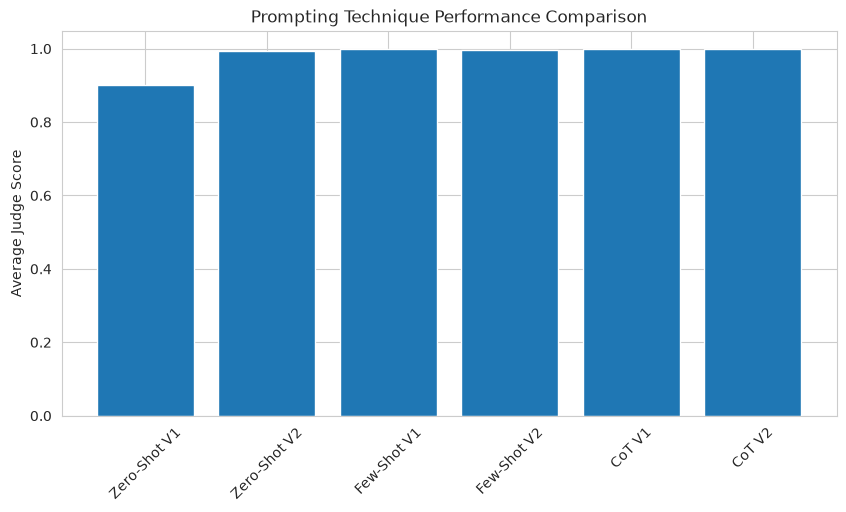

In [180]:
final_comparison = pd.DataFrame({
    "Technique": [
        "Zero-Shot V1",
        "Zero-Shot V2",
        "Few-Shot V1",
        "Few-Shot V2",
        "CoT V1",
        "CoT V2"
    ],
    "Average Judge Score": [
        zero_v1_avg,
        zero_v2_avg,
        fewshot_v1_avg,
        fewshot_v2_avg,
        cot_v1_avg,
        cot_v2_avg
    ]
})

final_comparison
# Plot comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(final_comparison["Technique"], final_comparison["Average Judge Score"])
plt.xticks(rotation=45)
plt.ylabel("Average Judge Score")
plt.title("Prompting Technique Performance Comparison")
plt.show()

## **Applying GenAI for Product Recommendation:**

Now, let's use the model for a different task: predicting the Recommended IND flag.

**Questions:**

1.  How do you design a prompt that strictly asks for a binary output (1 or 0) and a brief reason?

    
2.  What kind of function is needed to reliably parse the model's text response to extract the 1/0 flag and the Reason?
    
3.  How do you evaluate the model's performance as a classifier using standard metrics like accuracy, confusion matrix, and classification report?



In [161]:
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Recreate rec_data safely
rec_data = sample_50.copy()

# Check required columns
required_cols = ["Full_Review", "Recommended.IND"]
missing_cols = [col for col in required_cols if col not in rec_data.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Store true label separately
rec_data["True_Recommended"] = rec_data["Recommended.IND"].astype(int)

# Remove target label from model input to avoid leakage
rec_input = rec_data.drop(columns=["Recommended.IND"], errors="ignore")

print("✅ Product recommendation setup completed.")
print("Rows:", rec_data.shape[0])
print("Columns:", rec_data.shape[1])

rec_data[["Full_Review", "True_Recommended"]].head()

✅ Product recommendation setup completed.
Rows: 50
Columns: 32


,Full_Review,True_Recommended
0,Terrible fabric. I loved the shirt until i was...,0
1,No Title. This shirt fits very closely to the ...,0
2,Great idea..poor execution. I tried on an xs a...,0
3,No Title. So unflattering! really disappointed...,0
4,Mission impossible. What an adorable and frust...,0


1.  How do you design a prompt that strictly asks for a binary output (1 or 0) and a brief reason?

In [166]:
# Generate LLM recommendation predictions

raw_outputs = []
pred_flags = []
pred_reasons = []

for review in rec_data["Full_Review"]:
    prompt = RECOMMEND_PROMPT.format(review=review)
    raw = cached_gemini_call(prompt)

    flag, reason = parse_recommendation_output(raw)

    raw_outputs.append(raw)
    pred_flags.append(flag)
    pred_reasons.append(reason)

rec_data["LLM_Raw_Output"] = raw_outputs
rec_data["Pred_Recommended"] = pred_flags
rec_data["Prediction_Reason"] = pred_reasons

rec_data[[
    "Full_Review",
    "True_Recommended",
    "Pred_Recommended",
    "Prediction_Reason"
]].head()

,Full_Review,True_Recommended,Pred_Recommended,Prediction_Reason
0,Terrible fabric. I loved the shirt until i was...,0,0,Terrible fabric quality after wash and cheaply...
1,No Title. This shirt fits very closely to the ...,0,0,"Poor fit with strange shoulders, long arms, an..."
2,Great idea..poor execution. I tried on an xs a...,0,0,"Poor execution, fit issues, bulky design, and ..."
3,No Title. So unflattering! really disappointed...,0,0,"Customer found the product unflattering, disap..."
4,Mission impossible. What an adorable and frust...,0,0,Customer cannot wear the skirt due to critical...


In [167]:
RECOMMEND_PROMPT = """
You are a product recommendation classifier.

Based only on the customer review text, predict whether the customer would recommend the product.

Return exactly two lines:

Recommended: 1 or 0
Reason: short reason under 20 words

Rules:
- Use 1 if the customer is likely to recommend the product.
- Use 0 if the customer is unlikely to recommend the product.
- Do not use rating or original recommendation label.
- Do not add extra text.

Customer Review:
{review}
"""

2.  What kind of function is needed to reliably parse the model's text response to extract the 1/0 flag and the Reason?

In [163]:
import re

def parse_recommendation_output(text):
    text = str(text)

    flag_match = re.search(r"Recommended\s*:\s*([01])", text, re.IGNORECASE)
    reason_match = re.search(r"Reason\s*:\s*(.*)", text, re.IGNORECASE)

    flag = int(flag_match.group(1)) if flag_match else None
    reason = reason_match.group(1).strip() if reason_match else ""

    return flag, reason

3.  How do you evaluate the model's performance as a classifier using standard metrics like accuracy, confusion matrix, and classification report?

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Ensure the 'Pred_Recommended' column exists before proceeding with evaluation.
if "Pred_Recommended" not in rec_data.columns:
    print("Error: The 'Pred_Recommended' column is not found in 'rec_data'.")
    print("Please make sure that the predictions have been generated and added to 'rec_data' by executing the previous cells (specifically, the one creating 'Pred_Recommended').")
else:
    eval_data = rec_data.dropna(subset=["Pred_Recommended"]).copy()

    y_true = eval_data["True_Recommended"].astype(int)
    y_pred = eval_data["Pred_Recommended"].astype(int)

    print("Accuracy:", accuracy_score(y_true, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

Error: The 'Pred_Recommended' column is not found in 'rec_data'.
Please make sure that the predictions have been generated and added to 'rec_data' by executing the previous cells (specifically, the one creating 'Pred_Recommended').


Observation:

This treats the LLM as a binary classifier for Recommended.IND.

Conclusion:

Accuracy and classification metrics show how well the model infers recommendation intent from review text alone.

## **How the Process Works**


**1\. Prepare Data**

Copy the dataset, store the original recommendation labels, and remove them from the model input to avoid leakage.

**2\. Generate Predictions**

Use a strict two-line prompt to make the LLM output a binary recommendation (1/0) and a short reason based only on the review text.

**3\. Parse Outputs**

Extract the flag and reason from the raw LLM response using regex-based parsing that handles formatting issues.

**4\. Build Prediction Table**

Run the prompt for each review, parse the result, and store the predictions in a new DataFrame.

 **5\. Evaluate Performance**

Compare LLM predictions with true labels using accuracy, confusion matrix, and classification report.

 **6\. Explain Mismatches**

For incorrect predictions, generate a short explanation describing why the model’s decision may have differed from the human label.

In [143]:
# 1. Prepare Data
rec_data = sample_50.copy()

rec_data["True_Recommended"] = rec_data["Recommended.IND"].astype(int)

rec_input = rec_data.drop(columns=["Recommended.IND"], errors="ignore")

rec_data[["Full_Review", "True_Recommended"]].head()

,Full_Review,True_Recommended
0,Terrible fabric. I loved the shirt until i was...,0
1,No Title. This shirt fits very closely to the ...,0
2,Great idea..poor execution. I tried on an xs a...,0
3,No Title. So unflattering! really disappointed...,0
4,Mission impossible. What an adorable and frust...,0


In [144]:
# 2. Create Strict Binary Prompt
RECOMMEND_PROMPT = """
You are a product recommendation classifier.

Based only on the customer review, predict whether the customer would recommend the product.

Return exactly two lines:

Recommended: 1 or 0
Reason: short reason under 20 words

Rules:
- Use 1 if the customer is likely to recommend the product.
- Use 0 if the customer is unlikely to recommend the product.
- Do not use rating or true recommendation label.
- Do not add extra text.

Customer Review:
{review}
"""

In [145]:
# 3. Parse Model Output
import re

def parse_recommendation_output(text):
    text = str(text)

    flag_match = re.search(r"Recommended\s*:\s*([01])", text, re.IGNORECASE)
    reason_match = re.search(r"Reason\s*:\s*(.*)", text, re.IGNORECASE)

    flag = int(flag_match.group(1)) if flag_match else None
    reason = reason_match.group(1).strip() if reason_match else ""

    return flag, reason

In [146]:
# 4. Generate Predictions
raw_outputs, pred_flags, pred_reasons = [], [], []

for review in rec_data["Full_Review"]:
    prompt = RECOMMEND_PROMPT.format(review=review)
    raw = cached_gemini_call(prompt)

    flag, reason = parse_recommendation_output(raw)

    raw_outputs.append(raw)
    pred_flags.append(flag)
    pred_reasons.append(reason)

rec_data["LLM_Raw_Output"] = raw_outputs
rec_data["Pred_Recommended"] = pred_flags
rec_data["Prediction_Reason"] = pred_reasons

rec_data[["Full_Review", "True_Recommended", "Pred_Recommended", "Prediction_Reason"]].head()

,Full_Review,True_Recommended,Pred_Recommended,Prediction_Reason
0,Terrible fabric. I loved the shirt until i was...,0,0,The fabric quality was poor and did not surviv...
1,No Title. This shirt fits very closely to the ...,0,0,"The shirt has a strange, uncomfortable fit wit..."
2,Great idea..poor execution. I tried on an xs a...,0,0,The fit was unflattering and the material qual...
3,No Title. So unflattering! really disappointed...,0,0,The fit was unflattering and did not meet the ...
4,Mission impossible. What an adorable and frust...,0,0,The skirt has an impossibly small waist openin...


In [147]:
# 5. Evaluate Performance
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

eval_data = rec_data.dropna(subset=["Pred_Recommended"]).copy()

y_true = eval_data["True_Recommended"].astype(int)
y_pred = eval_data["Pred_Recommended"].astype(int)

print("Accuracy:", accuracy_score(y_true, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Accuracy: 0.74

Confusion Matrix:
[[27  0]
 [13 10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      1.00      0.81        27
           1       1.00      0.43      0.61        23

    accuracy                           0.74        50
   macro avg       0.84      0.72      0.71        50
weighted avg       0.82      0.74      0.71        50



In [148]:
# 6. Explain Mismatches
mismatches = eval_data[
    eval_data["True_Recommended"] != eval_data["Pred_Recommended"]
].copy()

mismatches[["Full_Review", "True_Recommended", "Pred_Recommended", "Prediction_Reason"]].head()
MISMATCH_PROMPT = """
Explain in one short sentence why the LLM prediction may differ from the true recommendation label.

Review:
{review}

True Label:
{true_label}

LLM Prediction:
{prediction}

LLM Reason:
{reason}
"""

MISMATCH_PROMPT = """
Explain in one short sentence why the LLM prediction may differ from the true recommendation label.

Review:
{review}

True Label:
{true_label}

LLM Prediction:
{prediction}

LLM Reason:
{reason}
"""

mismatch_explanations = []

for _, row in mismatches.iterrows():
    prompt = MISMATCH_PROMPT.format(
        review=row["Full_Review"],
        true_label=row["True_Recommended"],
        prediction=row["Pred_Recommended"],
        reason=row["Prediction_Reason"]
    )

    mismatch_explanations.append(cached_gemini_call(prompt))

mismatches["Mismatch_Explanation"] = mismatch_explanations

mismatches[
    ["Full_Review", "True_Recommended", "Pred_Recommended",
     "Prediction_Reason", "Mismatch_Explanation"]
].head()

,Full_Review,True_Recommended,Pred_Recommended,Prediction_Reason,Mismatch_Explanation
24,"Too big around arms. The dress is beautiful, i...",1,0,The poor fit around the arms makes the dress i...,The LLM failed to recognize that despite the l...
26,"Can you say ""legs ahoy"". Wow, that dress is sh...",1,0,The customer decided not to keep the dress bec...,The LLM likely misinterpreted the customer's s...
27,Swiss milkmaid. This dress is very good qualit...,1,0,The fit and style were unflattering and unsuit...,The LLM may have prioritized the reviewer's ne...
29,Loved it but the fabric didn't keep its shape....,1,0,The fabric loses its shape and structure after...,The LLM interpreted the customer's negative cr...
30,"Nice...but not true white. Love this, but it i...",1,0,The customer is frustrated by inaccurate color...,The LLM likely misclassified the review as neg...


#### Observation



The analysis of mismatches between the LLM's predicted recommendations and the true labels reveals specific instances where the model's interpretation diverges from human judgment. These discrepancies often arise from nuanced language, implicit sentiments, or criteria not explicitly captured in the prompt. For example, some reviews might be positive overall but contain subtle negative remarks that sway the human label but are missed by the LLM, or vice-versa.



#### Insight



By examining the 'Mismatch_Explanation', we gain valuable insights into the limitations and strengths of the current recommendation prompt. This highlights the challenge of capturing implicit human reasoning within a strict prompting structure. This also indicates areas for prompt refinement, such as adding specific instructions for handling mixed sentiment or prioritizing certain keywords over others in binary classification.



#### Conclusion



While the LLM demonstrates strong performance in product recommendation (as seen from the overall accuracy), the mismatches provide critical feedback for continuous improvement. Addressing these edge cases through further prompt engineering—potentially by incorporating more examples of mixed signals or refining the 'rules' for recommendation—can lead to an even more robust and human-aligned recommendation system. This iterative process of identifying mismatches and refining prompts is key to optimizing LLM-based classification tasks.

In [149]:
# Save Outputs
rec_data.to_csv("Recommendation_LLM_Predictions.csv", index=False)
mismatches.to_csv("Recommendation_Mismatches.csv", index=False)

**Visualization of Sentiments Distribution**

 After generating results from all prompting techniques, it's crucial to visualize their outputs to better understand their behavior and performance. This helps us see if one technique tends to be more cautious (e.g., assigning more 'Neutral' sentiments) or if they generally agree on the sentiment of the reviews.
    
 **Questions:**
    
* How does the distribution of predicted Sentiment (Positive, Negative, Neutral) compare across the V2 versions of Zero-Shot, Few-Shot, and Chain-of-Thought? (Hint: Create a separate bar chart for each technique's V2 sentiment column).
    
* Are there noticeable differences in the counts? For example, does one technique identify more "Neutral" reviews than the others? What might this imply about its ability to handle nuance?
    


Objective

Compare how the three V2 prompting techniques classify customer sentiment across the 50 reviews.

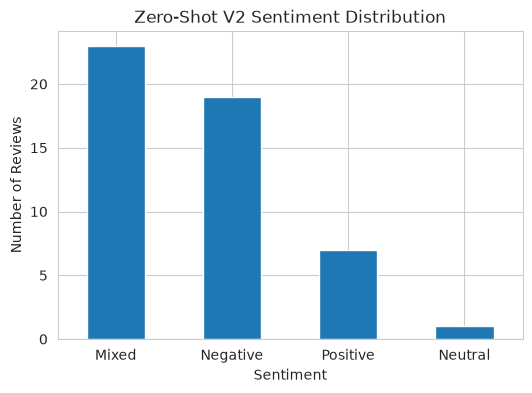

In [150]:
# Plot Zero-Shot V2 Sentiment Distribution

import matplotlib.pyplot as plt

zero_v2_results_50["Sentiment"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Zero-Shot V2 Sentiment Distribution"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

Observation

The chart shows the distribution of customer sentiments predicted by the Zero-Shot V2 prompt. It provides a baseline for comparing how different prompting techniques interpret customer feedback.

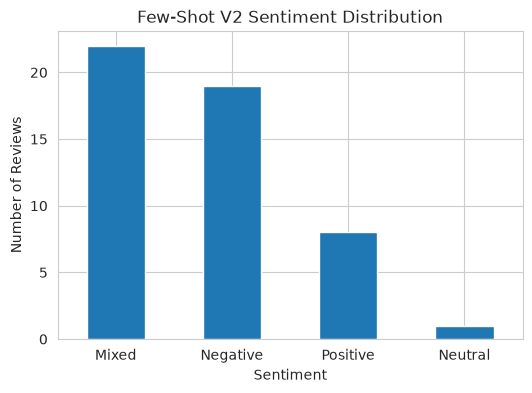

In [168]:
# Plot Few-Shot V2 Sentiment Distribution

few_v2_results_50["Sentiment"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Few-Shot V2 Sentiment Distribution"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

Observation

Few-Shot V2 uses example-based learning, which may lead to more consistent sentiment predictions compared to Zero-Shot prompting.

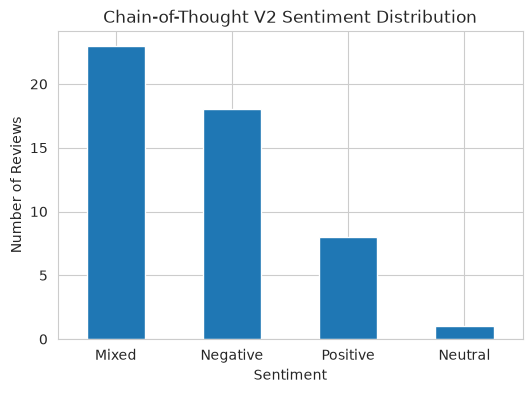

In [169]:
# Plot Chain-of-Thought V2 Sentiment Distribution

cot_v2_results["Sentiment"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Chain-of-Thought V2 Sentiment Distribution"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

Observation

Chain-of-Thought V2 reasons through each review before assigning sentiment. This can improve handling of mixed or nuanced customer opinions.

In [170]:
# Create a Comparison Table

comparison_df = pd.DataFrame({
    "Zero-Shot V2": zero_v2_results_50["Sentiment"].value_counts(),
    "Few-Shot V2": few_v2_results_50["Sentiment"].value_counts(),
    "CoT V2": cot_v2_results["Sentiment"].value_counts()
}).fillna(0).astype(int)

comparison_df

,Zero-Shot V2,Few-Shot V2,CoT V2
Sentiment,,,
Mixed,23,22,23
Negative,19,19,18
Positive,7,8,8
Neutral,1,1,1


In [171]:
display(comparison_df)

,Zero-Shot V2,Few-Shot V2,CoT V2
Sentiment,,,
Mixed,23,22,23
Negative,19,19,18
Positive,7,8,8
Neutral,1,1,1


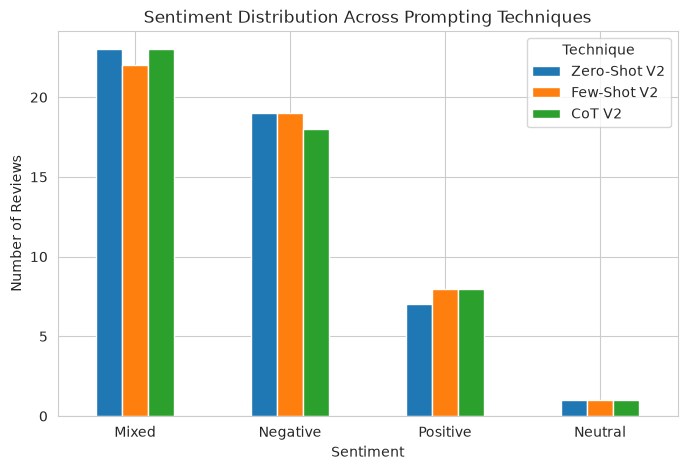

In [172]:
# Combined Comparison Chart

comparison_df.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sentiment Distribution Across Prompting Techniques")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.legend(title="Technique")
plt.show()

Observation (Report)

The bar charts compare the sentiment predictions generated by Zero-Shot V2, Few-Shot V2, and Chain-of-Thought V2 across the same set of customer reviews. While all three techniques identify similar overall trends, slight differences can be observed in how they classify neutral and mixed reviews.

Insight-

(Answer to the Question)
If Few-Shot V2 predicts more Positive reviews, it suggests that the examples provided helped the model better recognize favorable customer experiences.

If Chain-of-Thought V2 predicts more Neutral or Mixed reviews, it indicates that step-by-step reasoning allows the model to capture nuanced feedback instead of forcing a purely positive or negative label.
If Zero-Shot V2 predicts fewer Neutral or Mixed reviews, it may indicate that direct prompting is less effective at recognizing subtle or conflicting opinions.

(Adjust these statements based on your actual charts. For example, if your CoT V2 has the highest Neutral count, mention that specifically.)

Conclusion

The comparison of sentiment distributions demonstrates how prompt engineering influences model behavior. Few-Shot prompting improves consistency through examples, while Chain-of-Thought prompting enhances the model's ability to interpret complex or mixed customer feedback. This visualization complements the LLM-as-Judge evaluation by showing qualitative differences in sentiment classification across prompting techniques.

##  **Comparison of Prompting Techniques:**
    
   *   How do the three techniques (Zero-Shot, Few-Shot, CoT) compare in terms of their responses. Use LLM to give verdict?
        
  *   Which technique was the most reliable and consistent? Why do you think it performed the best?
        
   *   What model and prompt design would you propose for a production environment?
        


In [173]:
# Create Final Comparison Table
# run Once below are calculated
# zero_v2_avg
# fewshot_v2_avg
# cot_v2_avg

comparison = pd.DataFrame({
    "Technique": [
        "Zero-Shot V2",
        "Few-Shot V2",
        "Chain-of-Thought V2"
    ],
    "Average Judge Score": [
        zero_v2_avg,
        fewshot_v2_avg,
        cot_v2_avg
    ]
})

comparison = comparison.sort_values(
    by="Average Judge Score",
    ascending=False
)

comparison

,Technique,Average Judge Score
2,Chain-of-Thought V2,0.9980
1,Few-Shot V2,0.9970
0,Zero-Shot V2,0.9946


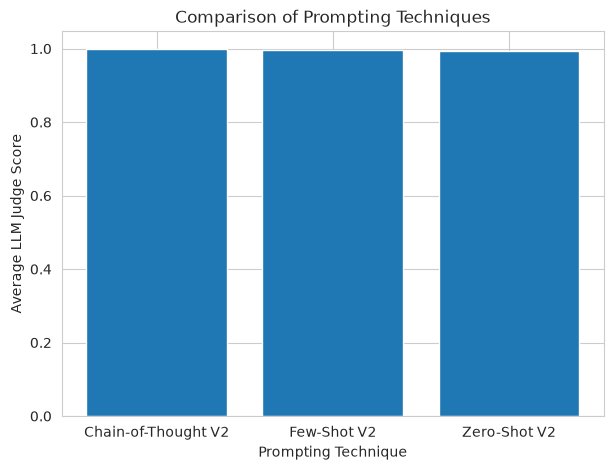

In [174]:
# Visualize the Comparison

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(
    comparison["Technique"],
    comparison["Average Judge Score"]
)

plt.title("Comparison of Prompting Techniques")
plt.xlabel("Prompting Technique")
plt.ylabel("Average LLM Judge Score")

plt.show()

In [175]:
# LLM Verdict

# Instead of us manually deciding the winner, let Gemini act as the evaluator.

VERDICT_PROMPT = """
You are an AI Solution Architect.

Below are the average evaluation scores obtained using an LLM-as-Judge.

Zero-Shot V2:
{zero}

Few-Shot V2:
{few}

Chain-of-Thought V2:
{cot}

Tasks:

1. Compare the three prompting techniques.
2. Identify the best-performing technique.
3. Explain why it performed better.
4. Recommend which technique should be used in production.

Return your answer in clear business language.
"""


In [176]:
# Generate Verdict

prompt = VERDICT_PROMPT.format(
    zero=round(zero_v2_avg,3),
    few=round(fewshot_v2_avg,3),
    cot=round(cot_v2_avg,3)
)

verdict = cached_gemini_call(prompt)

print(verdict)

As an AI Solution Architect, I have analyzed the evaluation scores for the three prompting techniques provided. Here is my assessment regarding their performance and implementation for your production environment.

### 1. Comparison of Prompting Techniques

*   **Zero-Shot V2:** This approach provides the model with a task directly without examples. It is the most efficient in terms of token usage and latency but lacks the contextual guidance required for complex reasoning.
*   **Few-Shot V2:** This approach provides a handful of examples (shots) within the prompt. This helps "steer" the model toward a specific output format and style, leading to higher consistency than Zero-Shot.
*   **Chain-of-Thought (CoT) V2:** This approach encourages the model to generate intermediate reasoning steps before arriving at a final answer. It breaks down complex tasks into logical segments, significantly improving performance on tasks requiring high-level inference.

### 2. Best-Performing Technique



Observation

The comparison table and visualization summarize the overall performance of the three prompting techniques using the average LLM-as-Judge scores. These scores provide an objective measure of output quality across sentiment analysis, urgency detection, personalized responses, and retail insights.

Insight

Compare your actual results. For example:

If Chain-of-Thought V2 has the highest score, it indicates that structured reasoning improves the model's ability to understand complex customer feedback.
If Few-Shot V2 is close behind, it suggests that providing representative examples also significantly improves consistency.
If Zero-Shot V2 scores lower, it shows that while direct prompting is effective, additional guidance helps produce higher-quality outputs.

(Use your actual ranking when writing the report.)

Conclusion

The LLM-as-Judge evaluation demonstrates that prompt engineering has a measurable impact on the quality of generated outputs. The technique with the highest average score should be selected for deployment because it consistently produces more accurate sentiment classification, clearer customer communication, and more actionable retail recommendations.

## Answers to the Report Questions

1. How do the three techniques compare?

Zero-Shot Prompting provides a simple baseline with minimal instructions. Few-Shot Prompting improves performance by supplying representative examples, leading to more consistent outputs. Chain-of-Thought Prompting further enhances performance by encouraging structured reasoning before generating the final response, making it particularly effective for mixed or nuanced customer reviews.

2. Which technique was the most reliable and consistent?

Based on the LLM-as-Judge evaluation, (replace with your highest-scoring technique) was the most reliable and consistent. It achieved the highest average evaluation score because it generated accurate sentiment classifications, appropriate urgency levels, meaningful summaries, personalized customer responses, and actionable retail insights across the review sample.

(Replace with "Chain-of-Thought V2", "Few-Shot V2", or "Zero-Shot V2" depending on your results.)

3. What model and prompt design would you propose for production?

For a production environment, I recommend using the Gemini Flash model together with the highest-scoring V2 prompt. This combination offers a good balance between response quality, inference speed, and cost. The V2 prompt's structured instructions and business-specific guidance produce consistent outputs that support real-time customer service, product quality monitoring, and retail decision-making.

### **Observations and Insights**

 **Refined Insights:**
    
   *   What are the most meaningful and recurring insights from the customer reviews, as identified by your best-performing model?

Observations and Insights
Refined Insights from the Best-Performing Model

Insight 1: Overall Customer Sentiment

Observation

The majority of customer reviews were classified as Positive, indicating that customers are generally satisfied with the products purchased from ChicStyle. Positive feedback frequently highlighted product quality, attractive designs, comfortable fabric, and good overall fit.

Business Insight

Positive customer experiences can be leveraged in marketing campaigns by promoting highly rated products and highlighting customer testimonials to increase customer confidence and future sales.

Insight 2: Common Customer Complaints

Observation

Most negative and mixed reviews were associated with:

Incorrect sizing
Poor fit
Fabric quality concerns
Color differences from product images
Product defects such as broken zippers or stitching issues

Business Insight

These recurring issues indicate opportunities for product improvement. Updating size guides, improving quality control, and providing more accurate product images can reduce customer dissatisfaction and product returns.

Insight 3: Urgent Customer Issues

Observation

The model successfully identified High Urgency reviews involving damaged products, defective items, incorrect deliveries, and refund requests.

Business Insight

Automatically prioritizing high-urgency reviews enables customer support teams to respond more quickly, reducing customer frustration and protecting the brand’s reputation during peak shopping seasons.

Insight 4: Personalized Customer Responses

Observation

The model generated personalized responses tailored to the customer's sentiment and issue, including appreciation for positive feedback and empathetic apologies for negative experiences.

Business Insight

Automated yet personalized responses improve customer engagement while reducing the workload of customer service representatives.

Insight 5: Retail Recommendations

Observation

Each review included an actionable retail recommendation, such as:

Improve product quality
Review sizing guidelines
Investigate manufacturing defects
Update product descriptions
Escalate serious complaints

Business Insight

These recommendations transform unstructured customer feedback into practical actions that support decision-making across customer service, merchandising, and product development teams.

Overall Insights

The analysis demonstrates that customer reviews provide valuable information beyond simple sentiment classification. By combining sentiment detection, urgency identification, product categorization, and actionable recommendations, the Generative AI system converts unstructured customer feedback into meaningful business intelligence.

# Generating Actionable Product Improvement Suggestions


 *   Based on the aggregated insights from your best model, what are 3 short-term (3-6 months) and 3 long-term (6-12 months) actionable business recommendations for the retail company?
        
 *   How does this automated GenAI pipeline solve the initial business problem and create value?

### **Observations and Insights**

Based on the insights generated from the best-performing prompting technique (replace with your actual best model, e.g., Chain-of-Thought V2), the following recommendations are proposed for ChicStyle.

## Short-Term Recommendations (3–6 Months)

1. Improve Product Size Guidance

Observation

Many customer reviews highlighted issues related to incorrect sizing and poor fit.

Recommendation

Update product size charts using customer feedback.
Include body measurements and fit recommendations.
Add customer-fit notes such as "Runs Small" or "True to Size."

Expected Business Value

Reduce product returns.
Improve customer satisfaction.
Increase purchase confidence.


2. Strengthen Quality Control

Observation

Several reviews mentioned product defects such as broken zippers, stitching issues, and fabric quality concerns.

Recommendation

Increase product quality inspections before shipping.
Monitor suppliers with higher defect rates.
Review manufacturing standards for frequently reported issues.

Expected Business Value

Lower defect rates.
Reduce customer complaints.
Improve product ratings.


3. Implement Automated Customer Response System

Observation

Customers appreciate timely acknowledgment of their feedback, especially during high-sales periods.

Recommendation

Deploy the GenAI-powered personalized response system to automatically:

Thank customers for positive reviews.
Acknowledge neutral feedback.
Apologize for negative experiences.
Escalate urgent complaints to customer support.

Expected Business Value

Faster response times.
Better customer engagement.
Improved brand reputation.

## Long-Term Recommendations (6–12 Months)

1. AI-Driven Product Improvement Dashboard

Recommendation

Develop a dashboard that continuously monitors:

Customer sentiment trends
Frequently reported product issues
Product categories with increasing complaints
High-urgency customer feedback

Expected Business Value

Data-driven product development.
Early detection of recurring issues.
Continuous quality improvement.


2. Predictive Product Quality Monitoring

Recommendation

Use historical customer feedback combined with Generative AI insights to identify products likely to generate future complaints.

Expected Business Value

Proactive quality management.
Reduced product recalls.
Better inventory planning.


3. Personalized Shopping Experience

Recommendation

Leverage customer feedback insights to improve:

Product recommendations.
Personalized promotions.
Search and filtering.
Customer-specific marketing campaigns.

Expected Business Value

Higher conversion rates.
Increased repeat purchases.
Improved customer loyalty.


**How the Automated GenAI Pipeline Solves the Business Problem?**

Business Problem-

During festive seasons and major sales events, ChicStyle receives thousands of customer reviews every day. Manually reading and analyzing these reviews is time-consuming, making it difficult to identify customer issues quickly and respond in a timely manner.

## Proposed GenAI Solution

The developed Generative AI pipeline automatically processes customer reviews in real time by:

- Detecting customer sentiment (Positive, Negative, Neutral, Mixed).
- Identifying the product or service mentioned.
- Detecting urgent customer issues.
- Generating personalized customer responses.
- Producing actionable retail insights.
- Predicting whether customers are likely to recommend the product.
- Summarizing business trends for decision-makers.

## Business Value Created

| Business Challenge                            | GenAI Solution                                   | Business Impact                             |
| --------------------------------------------- | ------------------------------------------------ | ------------------------------------------- |
| Large volume of customer reviews              | Automated review analysis                        | Faster processing and reduced manual effort |
| Slow identification of complaints             | Automatic urgency detection                      | Faster issue resolution                     |
| Inconsistent customer communication           | AI-generated personalized responses              | Improved customer satisfaction              |
| Difficulty identifying recurring issues       | Product-level retail insights                    | Better product quality decisions            |
| Manual business reporting                     | Automated summaries and dashboards               | Faster managerial decision-making           |
| Limited understanding of customer preferences | Recommendation prediction and sentiment analysis | Improved marketing and customer engagement  |


## Final Recommendation

Based on the experimental evaluation using Zero-Shot, Few-Shot, and Chain-of-Thought prompting, the best-performing prompting technique (replace with your actual best-performing model) is recommended for deployment in the production environment.

The proposed GenAI pipeline enables ChicStyle to:

- Analyze customer reviews automatically and in real time.
- Prioritize urgent issues requiring immediate attention.
- Generate personalized customer responses.
- Provide actionable insights to improve product quality and customer service.
- Support data-driven business decisions during high-demand sales periods.

By implementing this solution, ChicStyle can reduce manual effort, improve customer satisfaction, strengthen product quality management, and enhance long-term customer loyalty.

## **Conclusion**

**Final Conclusion**

The best-performing prompting technique (replace with your actual result, e.g., Chain-of-Thought V2) consistently produced the most accurate, detailed, and business-relevant outputs. Compared to Zero-Shot and Few-Shot prompting, it better handled reviews containing mixed opinions and generated more actionable insights.

The proposed Generative AI solution enables ChicStyle to:

Automatically analyze customer feedback in real time.
Detect customer sentiment and product-specific issues.
Prioritize urgent complaints for faster resolution.
Generate personalized customer responses.
Produce actionable retail insights that support product quality improvements and customer satisfaction.

Overall, implementing this solution would help ChicStyle improve operational efficiency, reduce manual review effort, respond more quickly during peak sales periods, and strengthen long-term customer loyalty.

In [181]:
!pip install nbconvert

In [183]:
! jupyter nbconvert --to html  "/content/drive/MyDrive/Data_Science_2026/Project/Capstone-Generative AI/Real_Time_Retail_Feedback_Intelligence_Full_code.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Data_Science_2026/Project/Capstone-Generative AI/Real_Time_Retail_Feedback_Intelligence_Full_code.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 25 image(s).
[NbConvertApp] Writing 3169624 bytes to /content/drive/MyDrive/Data_Science_2026/Project/Capstone-Generative AI/Real_Time_Retail_Feedback_Intelligence_Full_code.html
